# DATA 220 Section 23 Math Methods for DA

# Pair Programming - Lab Project: 2

### Group #7


### Aiswarya Raghavadesikan (014574599)

### Aryama Ray(017401124) 

## Q1: Recommender System (20 Points)

## 1. Download m1.zip file from the link (https://grouplens.org/datasets/movielens/1m/) (0 points)

#####  The  "ml-1m" folder containing 3 files - movies.dat, ratings.dat and users.dat are downloaded.

## 2. Load the movies and ratings data. (2 points)

In [79]:
import pandas as pd
import numpy as np

In [4]:
data1 = pd.read_table('http://localhost:8889/edit/Desktop/Desktop%20-%20Aiswarya%E2%80%99s%20MacBook%20Pro/LabProjects/DATA220/Lab2/ml-1m/movies.dat', delimiter='\t', header=None)


In [5]:
data1.head()

,0
0,<!DOCTYPE HTML>
1,<html>
2,<head>
3,"<meta charset=""utf-8"">"
4,<title>Jupyter Notebook</title>


In [6]:
data1.tail()

,0
253,if (!showNotebookNews) newsId.style.displa...
254,});
255,</script>
256,</body>
257,</html>


In [7]:
# data1.to_csv('movies.csv', index=False)

In [8]:
data2 = pd.read_table('http://localhost:8889/edit/Desktop/Desktop%20-%20Aiswarya%E2%80%99s%20MacBook%20Pro/LabProjects/DATA220/Lab2/ml-1m/ratings.dat', delimiter='\t', header=None)

In [9]:
# data2.to_csv('ratings.csv', index=False)

### Actions taken:
   - File opened to read with appropriate encoding (latin-1)
   - Formatted the files movies.dat, ratings.dat and users.dat
   - Splitted the file based on the appropriate columns name as specified in the README file.
   - Finally converted the .dat file to .csv file (after applying the above formats)

In [12]:
# Reading the 'movies.dat' file from the file path
with open('/Users/aiswaryaraghavadesikan/Desktop/Desktop - Aiswarya’s MacBook Pro/LabProjects/DATA220/Lab2/ml-1m/movies.dat', 'r', encoding='latin-1') as file:
    lines = file.readlines()

# Creating a list of dictionaries
movies_data = []
for line in lines:
    parts = line.strip().split("::")
    if len(parts) == 3:
        movie_id, title, genres = parts
        movie_id = int(movie_id)
        genres = genres.split('|')
        movies_data.append({'MovieID': movie_id, 'Title': title, 'Genres': genres})

# Creating a DataFrame from the list of dictionaries
movies_df = pd.DataFrame(movies_data)

# Convert the list of genres to a string with '|' separator
movies_df['Genres'] = movies_df['Genres'].apply(lambda x: '|'.join(x))

# Downloading the csv file (commented to avoid downloading the file)
# movies_df.to_csv('movies.csv', index=False)

In [13]:
data_movies = pd.read_csv('movies.csv')

In [14]:
data_movies.head()

,MovieID,Title,Genres
0,1,Toy Story (1995),"['Animation', ""Children's"", 'Comedy']"
1,2,Jumanji (1995),"['Adventure', ""Children's"", 'Fantasy']"
2,3,Grumpier Old Men (1995),"['Comedy', 'Romance']"
3,4,Waiting to Exhale (1995),"['Comedy', 'Drama']"
4,5,Father of the Bride Part II (1995),['Comedy']


In [93]:
data_movies.dtypes

MovieID     int64
Title      object
Genres     object
dtype: object

#### Data Exploration:  For "Movies" dataset

**Categorical data:**
   - Title       : The string datatype describing the movie title. 
   - Genres      : The string datatype describing the movie title. 

**Discrete data:** 
   - MovieID     : Discrete data giving the information about the unique entries of Movie ID.
 
 
 

In [15]:
with open('/Users/aiswaryaraghavadesikan/Desktop/Desktop - Aiswarya’s MacBook Pro/LabProjects/DATA220/Lab2/ml-1m/ratings.dat', 'r', encoding='latin-1') as file:
    lines = file.readlines()

In [16]:
ratings_data = []

In [17]:
for line in lines:
    parts = line.strip().split("::")
    if len(parts) == 4:
        user_id, movie_id, rating, timestamp = parts
        user_id = int(user_id)
        movie_id = int(movie_id)
        rating = float(rating)
        timestamp = int(timestamp)
        ratings_data.append({'UserID': user_id, 'MovieID': movie_id, 'Rating': rating, 'Timestamp': timestamp})

# Create a DataFrame from the list of dictionaries
ratings_df = pd.DataFrame(ratings_data)

# Save the DataFrame as a CSV file
# ratings_df.to_csv('ratings.csv', index=False)

In [18]:
data_ratings = pd.read_csv('ratings.csv')

In [19]:
data_ratings.head()

,UserID,MovieID,Rating,Timestamp
0,1,1193,5.0,2000-12-31 22:12:40
1,1,661,3.0,2000-12-31 22:35:09
2,1,914,3.0,2000-12-31 22:32:48
3,1,3408,4.0,2000-12-31 22:04:35
4,1,2355,5.0,2001-01-06 23:38:11


In [23]:
ratings_df = pd.read_csv('ratings.csv')

# Convert the 'Timestamp' column to a proper datetime format
ratings_df['Timestamp'] = pd.to_datetime(ratings_df['Timestamp'])



# ratings_df.to_csv('ratings.csv', index=False)

,UserID,MovieID,Rating,Timestamp
0,1,1193,5.0,2000-12-31 22:12:40
1,1,661,3.0,2000-12-31 22:35:09
2,1,914,3.0,2000-12-31 22:32:48
3,1,3408,4.0,2000-12-31 22:04:35
4,1,2355,5.0,2001-01-06 23:38:11


In [21]:
ratings_df.head()

,UserID,MovieID,Rating,Timestamp
0,1,1193,5.0,2000-12-31 22:12:40
1,1,661,3.0,2000-12-31 22:35:09
2,1,914,3.0,2000-12-31 22:32:48
3,1,3408,4.0,2000-12-31 22:04:35
4,1,2355,5.0,2001-01-06 23:38:11


In [24]:
data_ratings = pd.read_csv('ratings.csv')

In [25]:
data_ratings.head()

,UserID,MovieID,Rating,Timestamp
0,1,1193,5.0,2000-12-31 22:12:40
1,1,661,3.0,2000-12-31 22:35:09
2,1,914,3.0,2000-12-31 22:32:48
3,1,3408,4.0,2000-12-31 22:04:35
4,1,2355,5.0,2001-01-06 23:38:11


In [100]:
data_ratings.dtypes

UserID         int64
MovieID        int64
Rating       float64
Timestamp     object
dtype: object

#### Data Exploration: For "Ratings" dataset

**Discrete data:**

 - UserID : Discrete data (integer datatype) giving the information about the unique entries of UserID rating one or more movies.
 - MovieID: Discrete data (integer datatype) giving the information about the unique entries of MovieID receiving ratings from one or more users.

**Continuous data:**
 - Ratings : Continuous data (float datatype) giving information about the movie's ratings.

**Continuous data:**
 - Timestamp: Timestamp with date refers to categorical, ordinal, continuous or temporal data based on the context. Here we can say it is a continuous data role as it receives ratings on a particular date with timestamp details.

In [26]:
with open('/Users/aiswaryaraghavadesikan/Desktop/Desktop - Aiswarya’s MacBook Pro/LabProjects/DATA220/Lab2/ml-1m/users.dat', 'r', encoding='latin-1') as file:
    lines = file.readlines()

# Process the lines and create a list of dictionaries
users_data = []
for line in lines:
    parts = line.strip().split("::")
    if len(parts) == 5:
        user_id, gender, age, occupation, zip_code = parts
        user_id = int(user_id)
        age = int(age)
        users_data.append({'UserID': user_id, 'Gender': gender, 'Age': age, 'Occupation': occupation, 'ZipCode': zip_code})

# Create a DataFrame from the list of dictionaries
users_df = pd.DataFrame(users_data)

# Save the DataFrame as a CSV file
# users_df.to_csv('users.csv', index=False)

In [27]:
data_users = pd.read_csv('users.csv')

In [28]:
data_users.head()

,UserID,Gender,Age,Occupation,ZipCode
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


In [101]:
data_users.dtypes

UserID         int64
Gender        object
Age            int64
Occupation     int64
ZipCode       object
dtype: object

#### Data Exploration: For "Users" dataset

**Discrete data:**

 - UserID : Discrete data (integer datatype) giving the information about the unique entries of UserID.
 - Age: Discrete data (integer datatype) showing the information about the ages of the users.
 - Occupation: Discrete data (integer datatype) showing the information about the Occupation number of the users.
 - Zip Code: Discrete data (integer datatype) showing the information about the ZipCode of the users who provides the ratings to the movies.


**Categorical:**
 - Gender : Categorical data (String data type) having Male "M" or Female "F" based on the User details.
 

In [29]:
from IPython.display import Markdown

Markdown(r"$$V^{\intercal}$$")


$$V^{\intercal}$$

## 3. What do you mean by Singular Value Decomposition (SVD)(2 points)?

- Singular Value Decomposition (SVD) is a matrix factorization method.
- By decomposing a matrix into several components, the most useful and interesting information/ properties of the original matrix can be revealed while reducing the dimensionality of matrix.
- It is a powerful tool in data science, machine learning models for understanding, analyzing, and simplifying complex datasets. 
- For any given matrix (mxn) can be decomposed into three other matrices, providing a way to represent the original matrix in a simplified form. 

**Expression:**

Given A matrix which is of (m * n) shape.

  -  A   =    U Σ V^T 

- A is m * n given matrix
- U is m * m orthogonal matrix representing the left singular vectors of A. 
- Σ is m * n diagonal matrix containing the singular values of A.
- V^T is n * n transpose of an orthogonal matrix representing the right singular vectors of A.
 







## 4. Explain content-based vs collaborative recommendation. (2 points)

Here, the two recommender system algorithms are discussed below:
    - 1. Content based 
    - 2. Collaborative Recommendation

- The choice between content-based or collaborative or perhaps an hybrid approach depends on the characteristics of the data, the quality of available features, and the specific goals of the recommendation system. 

**Content-based Recommender System:**
 - Recommendation relies on the characteristics or features of items (movies in the given dataset) and the preferences expressed by the user. 
 - The idea is to recommend items similar to those the user has liked in the past based on the content features of the items.	

**Collaborative recommendation System:**
- Is based on the idea that users who agreed in the past tend to agree in the future. It doesn't rely on item features but rather on the historical preferences and behaviors of users. 
- Collaborative filtering can be user-based (recommend items to a user based on the preferences of users similar to them) or item-based (recommend items to a user based on the preferences of other users who liked similar items). 	

## 5. Create m x u matrix with movies as row and users as column. Normalize the matrix.(2 points)

In [155]:
mxu_matrix = ratings_df.pivot(index='MovieID', columns='UserID', values='Rating')

In [156]:
mxu_matrix = mxu_matrix.fillna(0)

In [157]:
mxu_matrix.head()

UserID,1,2,3,4,5,6,7,8,9,10,...,6031,6032,6033,6034,6035,6036,6037,6038,6039,6040
MovieID,,,,,,,,,,,,,,,,,,,,,
1,5.0,0.0,0.0,0.0,0.0,4.0,0.0,4.0,5.0,5.0,...,0.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,3.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [158]:
mxu_normalize = mxu_matrix.sub(mxu_matrix.mean(axis=1), axis=0)

In [159]:
mxu_normalize.head()

UserID,1,2,3,4,5,6,7,8,9,10,...,6031,6032,6033,6034,6035,6036,6037,6038,6039,6040
MovieID,,,,,,,,,,,,,,,,,,,,,
1,3.574007,-1.425993,-1.425993,-1.425993,-1.425993,2.574007,-1.425993,2.574007,3.574007,3.574007,...,-1.425993,2.574007,-1.425993,-1.425993,2.574007,-1.425993,-1.425993,-1.425993,-1.425993,1.574007
2,-0.371523,-0.371523,-0.371523,-0.371523,-0.371523,-0.371523,-0.371523,-0.371523,-0.371523,4.628477,...,-0.371523,-0.371523,-0.371523,-0.371523,-0.371523,-0.371523,-0.371523,-0.371523,-0.371523,-0.371523
3,-0.238742,-0.238742,-0.238742,-0.238742,-0.238742,-0.238742,-0.238742,-0.238742,-0.238742,-0.238742,...,-0.238742,-0.238742,-0.238742,-0.238742,0.761258,-0.238742,-0.238742,-0.238742,-0.238742,-0.238742
4,-0.076821,-0.076821,-0.076821,-0.076821,-0.076821,-0.076821,-0.076821,2.923179,-0.076821,-0.076821,...,-0.076821,-0.076821,-0.076821,-0.076821,1.923179,1.923179,-0.076821,-0.076821,-0.076821,-0.076821
5,-0.147351,-0.147351,-0.147351,-0.147351,-0.147351,-0.147351,-0.147351,-0.147351,-0.147351,-0.147351,...,-0.147351,-0.147351,-0.147351,-0.147351,0.852649,-0.147351,-0.147351,-0.147351,-0.147351,-0.147351


**Observation:**
   - In order to perform SVD, we need to create a movies and users matrix as rows and columns respectively based on the ratings matrix.
   - The  Ratings values are pivoted and to assign the values to zero to enable the matrix to be included with the normalized ratings values.


## 6. Perform SVD to get U, S and V. (4 points)

In [152]:
# Package Import
from scipy.linalg import svd

In [182]:
U, S, V = svd(mxu_normalize, full_matrices=False)


In [183]:
sigma_matrix = np.diag(S)

In [184]:
print(f"U : {U.shape}, sigma: {sigma_matrix.shape}, V: {V.shape}")

U : (3706, 3706), sigma: (3706, 3706), V: (3706, 6040)


In [185]:
U

array([[ 5.72245537e-02, -2.09461200e-02,  2.86333511e-02, ...,
        -2.13070811e-22, -1.58936708e-23, -7.93174242e-17],
       [ 2.69349804e-02, -2.97843268e-02, -8.62001932e-03, ...,
        -1.09381653e-17, -1.08044044e-16,  3.79076690e-17],
       [ 1.44300959e-02, -1.66998921e-02,  1.36557569e-02, ...,
        -1.45548124e-17, -5.22584332e-18,  1.91916220e-16],
       ...,
       [ 3.50288960e-03,  1.87545849e-03,  1.91670702e-03, ...,
         5.87291774e-17,  1.10592503e-17, -1.07686978e-16],
       [ 8.19971409e-04,  2.26486119e-03,  3.47436586e-03, ...,
         6.21321215e-17,  1.05562431e-16, -4.33375549e-16],
       [ 1.25419482e-02,  5.02192377e-03,  2.20808096e-02, ...,
        -5.96756832e-17,  6.78673649e-17,  3.87878396e-17]])

In [186]:
S

array([1.29873715e+03, 6.71343541e+02, 5.74547984e+02, ...,
       1.04420671e-13, 1.04420671e-13, 8.04998905e-14])

In [187]:
V

array([[-0.00713393, -0.00064038, -0.00672473, ..., -0.01136667,
        -0.00349382,  0.01328564],
       [ 0.00164099, -0.00270126, -0.00334737, ...,  0.00180896,
         0.0187621 ,  0.04080156],
       [ 0.00214622, -0.00020048, -0.00395618, ..., -0.0005622 ,
        -0.01089622, -0.00363312],
       ...,
       [ 0.00046296,  0.00665695,  0.00696366, ..., -0.004478  ,
         0.00027179, -0.00405395],
       [-0.02807539, -0.01269784, -0.03328292, ..., -0.01513222,
        -0.00333881,  0.00616033],
       [ 0.1611393 ,  0.00493524,  0.0158409 , ..., -0.00035329,
         0.01954026,  0.0029169 ]])

In [188]:
sigma_matrix

array([[1.29873715e+03, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 6.71343541e+02, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 5.74547984e+02, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        1.04420671e-13, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 1.04420671e-13, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 8.04998905e-14]])

In [189]:
sigma_matrix.shape

(3706, 3706)

In [190]:
SVD_matrix = U @ np.dot(sigma_matrix,V)

In [191]:
SVD_matrix.shape

(3706, 6040)

**Observation:**
   - Using scipy linalg package svd is performed.
   - The matrix decomposition is possible when we normalize the matrix and perform Singular Value decomposition to it to get a constructed resultant matrix.
   - Here we have, U : (3706, 3706), sigma: (3706, 3706), V: (6040, 6040) on setting the full matrices to True.
   - However, the matrix we could get here after SVD is a rectangular matrix on the V matrix
      U : (3706, 3706), sigma: (3706, 3706), V: (3706, 6040) as per the normalization process carried.
    

## 7. Select top 50 components from S. (2 point)

In [68]:
# Packages import

from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds

In [69]:
mxu_sparse = csr_matrix(mxu_normalize)

In [70]:
U_k, Sigma_k , V_k = svds(mxu_sparse, k= 50)

In [71]:
U_k = np.flip(U_k, axis=1)
Sigma_k = np.flipud(Sigma_k)
V_k = np.flipud(V_k)

In [72]:
Sigma_k_50 = np.diag(Sigma_k)

In [74]:
Sigma_k_50.shape

(50, 50)

In [75]:
#Printing the new U, Sigma and V for K = 50 components
(U_k.shape, Sigma_k_50.shape, V_k.shape)

((3706, 50), (50, 50), (50, 6040))

In [200]:
Sigma_k_50

array([[1298.7371535 ,    0.        ,    0.        , ...,    0.        ,
           0.        ,    0.        ],
       [   0.        ,  671.34354097,    0.        , ...,    0.        ,
           0.        ,    0.        ],
       [   0.        ,    0.        ,  574.54798415, ...,    0.        ,
           0.        ,    0.        ],
       ...,
       [   0.        ,    0.        ,    0.        , ...,  149.32202449,
           0.        ,    0.        ],
       [   0.        ,    0.        ,    0.        , ...,    0.        ,
         147.50259488,    0.        ],
       [   0.        ,    0.        ,    0.        , ...,    0.        ,
           0.        ,  146.84737883]])

**Observation:**

  - Using csr_matrix, it allows the efficient arithmetic operations on sparse matrices, making it suitable for mathematical computations involving sparse data.
  - Here it is performed for making it more memory-efficient compared to dense representations for matrices with a significant number of zero entries.
  - After selecting the top 50 components we can observe the size of the matrices changed as per the requirement:
     - U_k = (3706, 50)
     - Sigma_k_50 = (50, 50)
     - V_k = (50, 6040)
 
    Note: k denotes top 50 components

## 8. Get the top 50 eigenvectors using eigenvalues. (2 point)

In [193]:
movie_transpose_movie = np.dot(mxu_normalize.T, mxu_normalize)

In [194]:
# Eigen value decomposition
eigen_values, eigen_vectors = np.linalg.eig(movie_transpose_movie)

In [195]:
# Sort Eigen vectors based on largest eigen values (descending sort)
eigen_indices = np.argsort(eigen_values)[::-1]


In [196]:
# For top 50 eigenvectors
eigen_vectors_50 = eigen_vectors[:, eigen_indices[:50]]

eigen_vectors_50.shape

(6040, 50)

In [199]:
eigen_vectors_50

array([[-7.13393053e-03+0.j,  1.64099327e-03+0.j, -2.14622406e-03+0.j,
        ...,  5.93713869e-03+0.j,  5.95650709e-03+0.j,
        -1.92305260e-03+0.j],
       [-6.40383513e-04+0.j, -2.70126226e-03+0.j,  2.00478360e-04+0.j,
        ..., -1.02650386e-05+0.j, -6.98621978e-03+0.j,
         1.28333884e-02+0.j],
       [-6.72473390e-03+0.j, -3.34737240e-03+0.j,  3.95617989e-03+0.j,
        ..., -2.71745194e-03+0.j, -6.17870453e-03+0.j,
        -1.71058911e-02+0.j],
       ...,
       [-1.13666709e-02+0.j,  1.80896437e-03+0.j,  5.62198713e-04+0.j,
        ...,  3.86190451e-03+0.j, -1.21471781e-02+0.j,
         2.75605839e-03+0.j],
       [-3.49381899e-03+0.j,  1.87620989e-02+0.j,  1.08962191e-02+0.j,
        ...,  1.50272389e-03+0.j, -5.32028005e-03+0.j,
        -8.38519634e-04+0.j],
       [ 1.32856412e-02+0.j,  4.08015550e-02+0.j,  3.63311909e-03+0.j,
        ..., -1.90445430e-02+0.j,  9.47302822e-04+0.j,
         1.48134117e-02+0.j]])

**Observation:**

 - The purpose of eigen values and eigen vectors in machine learning models is to help understand how the data performs in an coordinate system.
- Process of rotating axis, stretching based on scalar eigen values and rotate to have a different view of the data. 
- Various use cases of Eigen Value and eigen Vectors are Principle Component Analysis, Image compressions and reconstructions, Google Page Rank algorithm.

## 9. Using cosine similarity, find 10 closest movies using the 50 components from SVD. (2 points)


In [92]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np


normalized_U_k = U_k / np.linalg.norm(U_k, axis=1, keepdims=True)

movies_index = 0

movies_cosine_similarity = cosine_similarity(normalized_U_k[movies_index].reshape(1, -1), normalized_U_k)

scores_cosine_similarity = movies_cosine_similarity.flatten()

# Finding the 10 closest movies
closest_10_movies_indices = np.argsort(scores_cosine_similarity)[::-1][1:11]

closest_10_moviestitles = movies_df.iloc[closest_10_movies_indices]['Title']

closest_10_moviestitles

2898           Bad Seed, The (1956)
33                      Babe (1995)
2162                Rounders (1998)
2128               Firelight (1997)
2191                  Wisdom (1986)
574     Hour of the Pig, The (1993)
2941                 Rosetta (1999)
517        Romeo Is Bleeding (1993)
2483     My Boyfriend's Back (1993)
1743                  Paulie (1998)
Name: Title, dtype: object

**Observation:**

- The purpose of cosine similarity is to measure the cosine of the angle between two vectors, providing a metric for similarity in orientation regardless of vector magnitude.
- Displaying the MovieID and Title of the movie based on the movie_index that is specified along with all other movies in the dataset where the Movies with the highest similarity scores are fetched.
- Finally the result of top 10 closest movies are chosen based on their feature vectors denoted by the normalized_U_k matrix here.

- Use cases: Text mining, information retrieval, and recommendation systems to assess the similarity between documents or items represented as vectors.

## 10. Discuss results of above SVD methods. (2 point)

**k= 50 outcome:**
 - Helped to choose the most significant features or patterns in the data.
 - Helped to condense the mxu_matrix to 
 
**cosine similarity for closest top 10 movies:**
- Based on the reduced dimensionality the cosine similarity is performed.
- Can infer that the movies with higher cosine similarity are likely to be enjoyed by similar groups of users.
- Hence we can say that the **top 10 movies** identified using cosine similarity are the movies that are most similar to a particular reference movie in terms of user ratings.
- From SVD, we obtained these recommendations as they are made by comparing the reduced-dimensional representations of movies.

**Overall outcome:**
- The results provide insights into which movies are most similar to each other based on user ratings, considering the reduced-dimensional representation obtained through SVD.

# DATA220_Section23_Math Method for Data Analysis
## Pair Programming Lab2


### Aiswarya Raghavadesikan (014574599)
### Aryama Ray (017401124)

## Question 2:

### Importing the Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

## Data Exploration

## 2.1.Start by importing the dataset and exploring its structure.

### Loading housing price dataset

In [3]:
house_price= pd.read_csv('HousePrice.csv')

### Checking few data from houseprice


In [4]:
house_price.head()

,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,SalesPrice
0,5/2/14 0:00,3,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,313000.0
1,5/2/14 0:00,5,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,2384000.0
2,5/2/14 0:00,3,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,342000.0
3,5/2/14 0:00,3,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,420000.0
4,5/2/14 0:00,4,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,550000.0


### Checking the shape of the dataset


In [5]:
house_price.shape

(4600, 14)

### Checking the columns of the dataset

In [6]:
house_price.columns

Index(['date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'SalesPrice'],
      dtype='object')

### Checking the datatype of the attributes

In [7]:
house_price.dtypes

date              object
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
SalesPrice       float64
dtype: object

## 2.2. What are the features and the target variable?

- House Price dataset has 4600 records and 14 columns such as: date, bedroom count, bathroom count, living area sqft details, lot sqft , number of floors, waterfront option, view, condition of the house, sqft above and basement sqft area, year when the house was built, renovation year etc.
- These attributes contribute towards determining the price of the house along with the variable - SalesPrice , which is the selling price of the house. 
- So the target variable for these dataset is SalesPrice whereas other variables are different features.

## 2.3. How many samples are in the dataset? Are there any missing values?

In [8]:
house_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   bedrooms       4600 non-null   int64  
 2   bathrooms      4600 non-null   float64
 3   sqft_living    4600 non-null   int64  
 4   sqft_lot       4600 non-null   int64  
 5   floors         4600 non-null   float64
 6   waterfront     4600 non-null   int64  
 7   view           4600 non-null   int64  
 8   condition      4600 non-null   int64  
 9   sqft_above     4600 non-null   int64  
 10  sqft_basement  4600 non-null   int64  
 11  yr_built       4600 non-null   int64  
 12  yr_renovated   4600 non-null   int64  
 13  SalesPrice     4600 non-null   float64
dtypes: float64(3), int64(10), object(1)
memory usage: 503.3+ KB


There are 4600 data in these dataset along with 14 features including the target variable. Also, some these attributes are having null values.
We will now take a count of null values in each attribute.

In [9]:
house_price.isnull().sum()

date             0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
SalesPrice       0
dtype: int64

In [10]:
date_zero_cnt= (house_price['date'] == 0).sum()
print('date_zero_cnt :',date_zero_cnt)

bedrooms_zero_cnt= (house_price['bedrooms'] == 0).sum()
print('bedrooms_zero_cnt :',bedrooms_zero_cnt)

bathrooms_zero_cnt= (house_price['bathrooms'] == 0).sum()
print('bathrooms_zero_cnt :',bathrooms_zero_cnt)

sqft_living_zero_cnt= (house_price['sqft_living'] == 0).sum()
print('sqft_living_zero_cnt :',sqft_living_zero_cnt)

sqft_lot_zero_cnt= (house_price['sqft_lot'] == 0).sum()
print('sqft_lot_zero_cnt :',sqft_lot_zero_cnt)

floors_zero_cnt= (house_price['floors'] == 0).sum()
print('floors_zero_cnt :',floors_zero_cnt)


waterfront_zero_cnt= (house_price['waterfront'] == 0).sum()
print('waterfront_zero_cnt :',waterfront_zero_cnt)

view_zero_cnt= (house_price['view'] == 0).sum()
print('view_zero_cnt :',view_zero_cnt)

condition_zero_cnt= (house_price['condition'] == 0).sum()
print('condition_zero_cnt :',condition_zero_cnt)

sqft_above_zero_cnt= (house_price['sqft_above'] == 0).sum()
print('sqft_above_zero_cnt :',sqft_above_zero_cnt)

sqft_basement_zero_cnt= (house_price['sqft_basement'] == 0).sum()
print('sqft_basement_zero_cnt :',sqft_basement_zero_cnt)

yr_built_zero_cnt= (house_price['yr_built'] == 0).sum()
print('yr_built_zero_cnt :',yr_built_zero_cnt)

yr_renovated_zero_cnt= (house_price['yr_renovated'] == 0).sum()
print('yr_renovated_zero_cnt :',yr_renovated_zero_cnt)

SalesPrice_zero_cnt= (house_price['SalesPrice'] == 0).sum()
print('SalesPrice_zero_cnt :',SalesPrice_zero_cnt)

date_zero_cnt : 0
bedrooms_zero_cnt : 2
bathrooms_zero_cnt : 2
sqft_living_zero_cnt : 0
sqft_lot_zero_cnt : 0
floors_zero_cnt : 0
waterfront_zero_cnt : 4567
view_zero_cnt : 4140
condition_zero_cnt : 0
sqft_above_zero_cnt : 0
sqft_basement_zero_cnt : 2745
yr_built_zero_cnt : 0
yr_renovated_zero_cnt : 2735
SalesPrice_zero_cnt : 49


Following attributes are having zero value fields:
 -  bedrooms_zero_cnt,
 -  bathrooms_zero_cnt,
 -  waterfront_zero_cnt,
 -  view_zero_cnt,
 -  sqft_basement_zero_cnt,
 -  yr_renovated_zero_cnt
 -  SalesPrice_zero_cnt   

 But, considering the house sales price prediction, a house might not have view or waterfront. So, the corresponding count might be zero. Also, if it is new house, then renovation year might become zero.A house may not have basement as well which justifies the basement sqft value as zero. But Salesprice cannot be zero given the house is already sold.

 We will replace rest of the zero values with null values.


In [11]:
house_price['bedrooms'] = house_price['bedrooms'].replace(0,np.nan)
house_price['bathrooms'] = house_price['bathrooms'].replace(0,np.nan)
house_price['SalesPrice'] = house_price['SalesPrice'].replace(0,np.nan)

####  Checking null values in each columns

In [12]:
house_price.isnull().sum()

date              0
bedrooms          2
bathrooms         2
sqft_living       0
sqft_lot          0
floors            0
waterfront        0
view              0
condition         0
sqft_above        0
sqft_basement     0
yr_built          0
yr_renovated      0
SalesPrice       49
dtype: int64

 - Bedrooms and Bathrooms count are numeric categorical variables. So we will replace null values for these attributes with corresponding mode values.
 - Sales Price for a house is continuous variable, hence null imputation will be done using median values.
    

In [13]:
house_price['bedrooms'].fillna(value = house_price['bedrooms'].mode(), inplace = True)
house_price['bathrooms'].fillna(value = house_price['bathrooms'].mode(), inplace = True)
house_price['SalesPrice'].fillna(value = house_price['SalesPrice'].median(), inplace = True)

## 2.4. Summarize the dataset. Min, max, avg, std dev, etc. stats for continuous features.

In [14]:
house_price.describe()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,SalesPrice
count,4598.000000,4598.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4.600000e+03
mean,3.402349,2.161755,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261,5.569162e+05
std,0.906273,0.782654,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536,5.609987e+05
min,1.000000,0.750000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000,7.800000e+03
25%,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000,3.281589e+05
50%,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000,4.650000e+05
75%,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000,6.549625e+05
max,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000,2.659000e+07


Continuous variables here are:
   - sqft_living
   - sqft_lot
   - sqft_above
   - sqft_basement
   - SalesPrice

    Lets filter only these continuous variables to check the summary statistics for them.
    

In [15]:
house_price_cont_var=house_price[['sqft_living','sqft_lot','sqft_above','sqft_basement','SalesPrice']]
house_price_cont_var.describe()

,sqft_living,sqft_lot,sqft_above,sqft_basement,SalesPrice
count,4600.000000,4.600000e+03,4600.000000,4600.000000,4.600000e+03
mean,2139.346957,1.485252e+04,1827.265435,312.081522,5.569162e+05
std,963.206916,3.588444e+04,862.168977,464.137228,5.609987e+05
min,370.000000,6.380000e+02,370.000000,0.000000,7.800000e+03
25%,1460.000000,5.000750e+03,1190.000000,0.000000,3.281589e+05
50%,1980.000000,7.683000e+03,1590.000000,0.000000,4.650000e+05
75%,2620.000000,1.100125e+04,2300.000000,610.000000,6.549625e+05
max,13540.000000,1.074218e+06,9410.000000,4820.000000,2.659000e+07


## 2.5. Visualize the distribution of each feature (sqft_living, sqft_lot, floors, SalesPrice)

In [16]:
house_price.head()

,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,SalesPrice
0,5/2/14 0:00,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,313000.0
1,5/2/14 0:00,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,2384000.0
2,5/2/14 0:00,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,342000.0
3,5/2/14 0:00,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,420000.0
4,5/2/14 0:00,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,550000.0


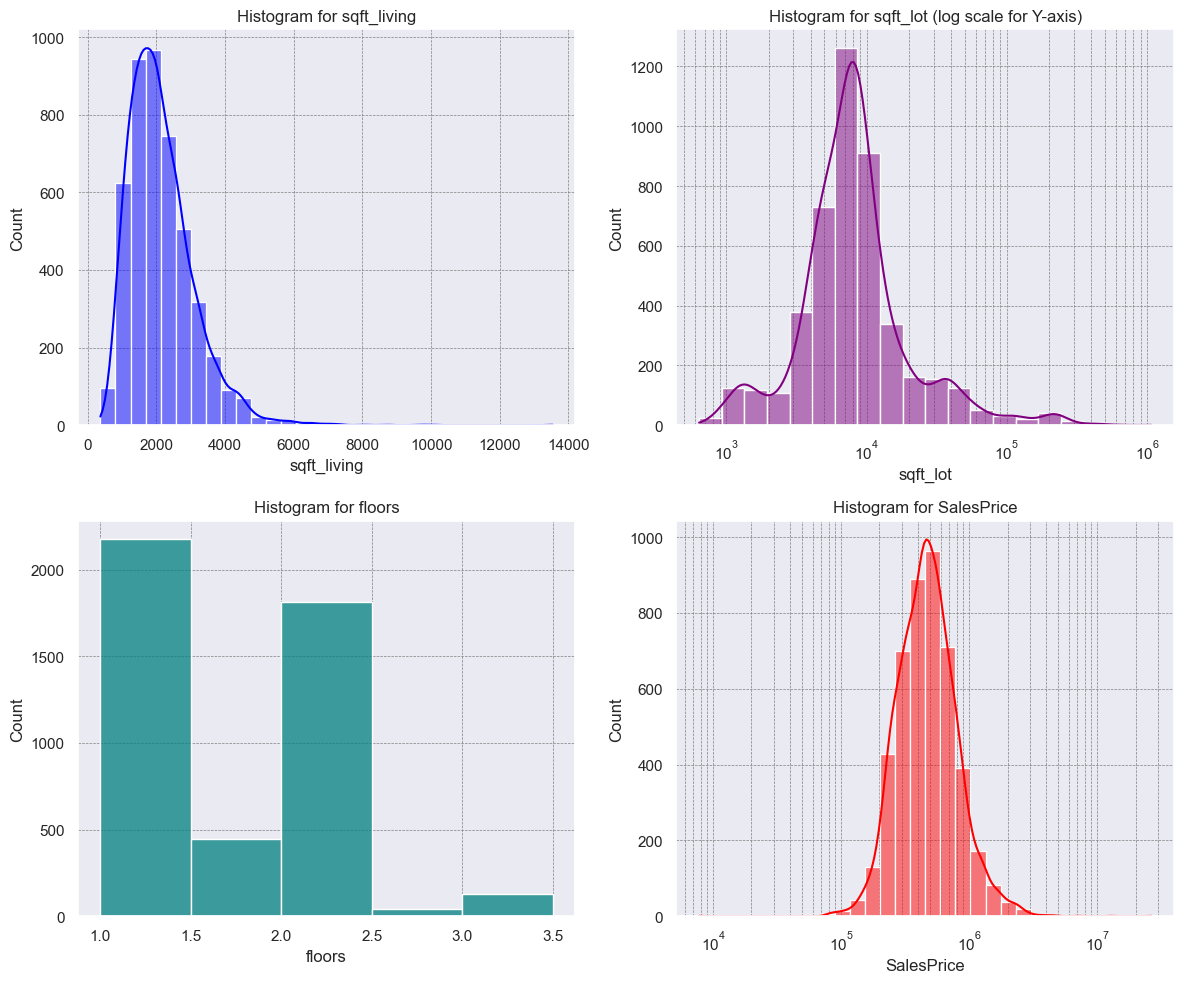

In [159]:
sns.set(style="darkgrid")
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))


sns.histplot(x='sqft_living', data=house_price, bins=30, kde=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('Histogram for sqft_living')
axes[0, 0].grid(True, linestyle='--', color='grey', which='both', linewidth=0.5)

sns.histplot(x='sqft_lot', data=house_price, bins=20, kde=True, ax=axes[0, 1], log_scale=(True, False), color='purple')
axes[0, 1].set_title('Histogram for sqft_lot (log scale for Y-axis)')
axes[0, 1].grid(True, linestyle='--', color='grey', which='both', linewidth=0.5)


sns.histplot(x='floors', data=house_price, bins=5, kde=False, ax=axes[1, 0], color='teal')
axes[1, 0].set_title('Histogram for floors')
axes[1, 0].grid(True, linestyle='--', color='grey', which='both', linewidth=0.5)

sns.histplot(x='SalesPrice', data=house_price, bins=30, kde=True, ax=axes[1, 1], log_scale=(True, False), color='red')
axes[1, 1].set_title('Histogram for SalesPrice')
axes[1, 1].grid(True, linestyle='--', color='grey', which='both', linewidth=0.5)

plt.savefig('histogram.png', dpi=1000)
plt.tight_layout()
plt.show()


**Observation:**

 - We have used histogram plot to visualize the distribution for the features: sqft_living, sqft_lot, floors and SalesPrice. 
 - The histogram plot shows a normal distribution for the features sqft_living, sqft_lot and SalesPrice. As the data for sqft_lot and SalesPrice is highly skewed, a log plot for the corresponding feature makes it easier to understand and visualize these parameters. 


## Linear Regression (Single Variable)

## 2.6. Implement your own linear regression model using the "sqft_lot" feature as the independent variable and "SalePrice" as the target variable. Print coef and intercept. 

In [204]:
import numpy as np
from sklearn.linear_model import LinearRegression

X = house_price[['sqft_lot']]  # Independent variable
y = house_price['SalesPrice']    # Target variable

# Create a linear regression model
model = LinearRegression()

# Fit the model
model.fit(X, y)

# Print coefficients and intercept
coef = model.coef_[0]
intercept = model.intercept_

print(f'Coefficient: {coef}')
print(f'Intercept: {intercept}')


Coefficient: 0.7988756407233849
Intercept: 545050.9360372869


### 2.7. Calculate the sum of squared errors for your model. (1 point)


In [205]:
from sklearn.metrics import mean_squared_error as mse

predictions = model.predict(X)
sse = mse(y, predictions) * len(y)

print(f'Sum of Squared Errors (SSE): {sse}')

r2 = r2_score(y, predictions)
print(f'R-squared (R2): {r2}')

Sum of Squared Errors (SSE): 1443615835122380.5
R-squared (R2): 0.002611240377665469


### 2.8. Plot the regression line along with the actual data points. (1 point)


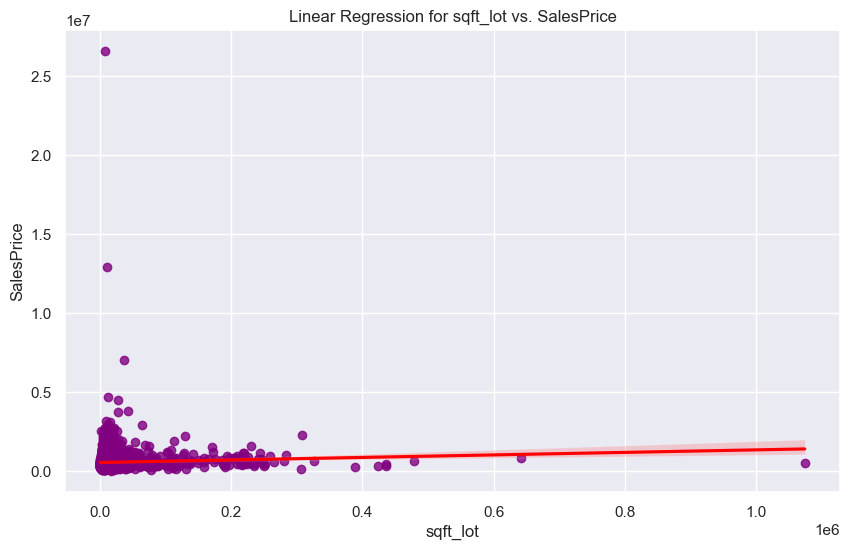

In [141]:
sns.set(style="darkgrid")
plt.figure(figsize=(10, 6))

sns.regplot(x='sqft_lot', y='SalesPrice', data=house_price, scatter_kws={'color': 'purple'}, line_kws={'color': 'red'})

plt.xlabel('sqft_lot')
plt.ylabel('SalesPrice')
plt.title('Linear Regression for sqft_lot vs. SalesPrice')

plt.show()


### 2.9. Use the LinearRegression function from sklearn.linear_model library and compare the coef and intercept with your model. (3 points)

In [142]:
X_with_intercept = np.c_[np.ones(X.shape[0]), X]
theta = np.linalg.inv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T @ y

New_coef = theta[1]
New_intercept = theta[0]

model = LinearRegression()
model.fit(X, y)
sklearn_coef = model.coef_[0]
sklearn_intercept = model.intercept_


print('Comparing the coef and intercept of the model')
print('\n')
print(f'Manual Implementation - Coefficient and Intercepts \n "New_coef": {New_coef}, \n Intercept: {New_intercept}')
print("\n")
print(f'Sklearn Linear Regression - Coefficient and Intercepts \n "sklearn_coef": {sklearn_coef}, \n Intercept: {sklearn_intercept}')


Comparing the coef and intercept of the model


Manual Implementation - Coefficient and Intercepts 
 "New_coef": 0.7988756407233877, 
 Intercept: 545050.9360372869


Sklearn Linear Regression - Coefficient and Intercepts 
 "sklearn_coef": 0.7988756407233849, 
 Intercept: 545050.9360372869


In [143]:
New_predictions = X_with_intercept @ theta
sklearn_predictions = model.predict(X)

New_sse = mse(y, New_predictions) * len(y)
sklearn_sse = mse(y, sklearn_predictions) * len(y)

print(f'Manual Implementation \n - Sum of Squared Errors (SSE): {New_sse}')
print('\n')
print(f'Sklearn LinearRegression \n - Sum of Squared Errors (SSE): {sklearn_sse}')


Manual Implementation 
 - Sum of Squared Errors (SSE): 1443615835122380.5


Sklearn LinearRegression 
 - Sum of Squared Errors (SSE): 1443615835122380.5


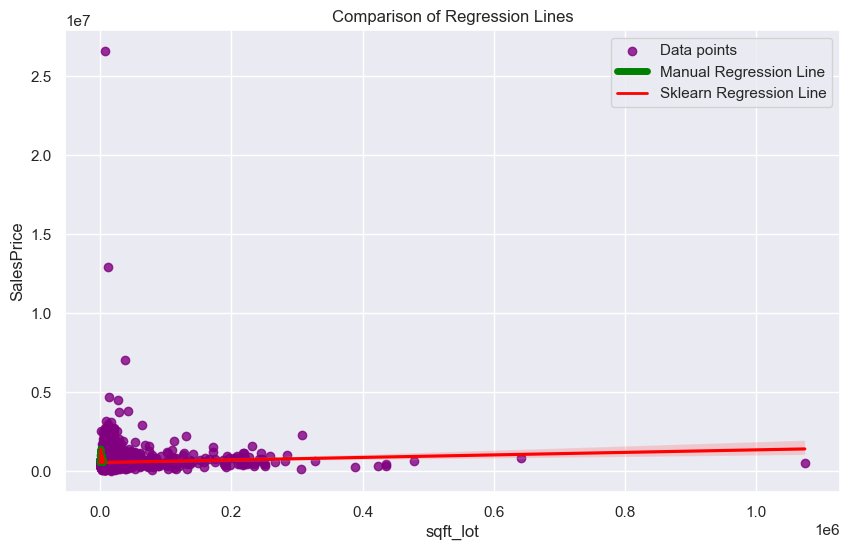

In [149]:
sns.set(style="darkgrid")

plt.figure(figsize=(10, 6))
sns.regplot(x='sqft_lot', y='SalesPrice', data=house_price, scatter_kws={'color': 'purple'}, line_kws={'color': 'red'}, label='Data points')
plt.plot(New_predictions, color='green', linewidth=5, label='Manual Regression Line')
plt.plot(sklearn_predictions, color='red', linewidth=2,  label='Sklearn Regression Line')


plt.xlabel('sqft_lot')
plt.ylabel('SalesPrice')
plt.title('Comparison of Regression Lines')
plt.legend()
plt.show()


## Linear Regression (Multivariate)

### 10. Use the LinearRegression function from sklearn.linear_model library to include multiple features sqft_living, sqft_lot and print the coef and intercept. (3 points)


In [151]:
X = house_price[['sqft_living', 'sqft_lot']]  
y = house_price['SalesPrice']                    


model = LinearRegression()

# Fit the model
model.fit(X, y)

# Print coefficients and intercept
coef = model.coef_
intercept = model.intercept_

print(f'Coefficients: {coef}')
print(f'Intercept: {intercept}')


Coefficients: [260.69917139  -0.67440183]
Intercept: 9206.834443249507


### 11. Print R-squared (R²) score. (1 point)


In [153]:
multi_predictions = model.predict(X)
R_squared = r2_score(y, multi_predictions)

print(f'For multiple features \n R-squared (R²) score: {R_squared}')

For multiple features 
 R-squared (R²) score: 0.19408281030398478


### 12. Visualize the relationships between the selected features and SalePrice. (2 points)

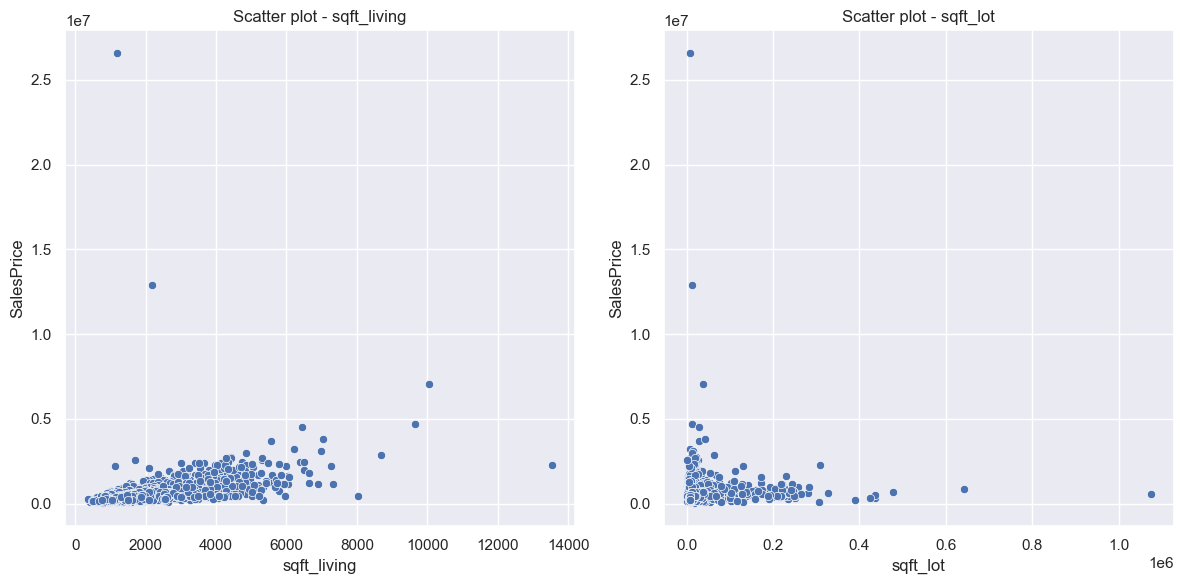

In [155]:
selected_features = ['sqft_living', 'sqft_lot']


sns.set(style="darkgrid")

fig, axes = plt.subplots(nrows=1, ncols=len(selected_features), figsize=(12, 6))

for i, feature in enumerate(selected_features):
    sns.scatterplot(x=feature, y='SalesPrice', data=house_price, ax=axes[i])
    axes[i].set_title(f'Scatter plot - {feature}')


plt.tight_layout()
plt.show()


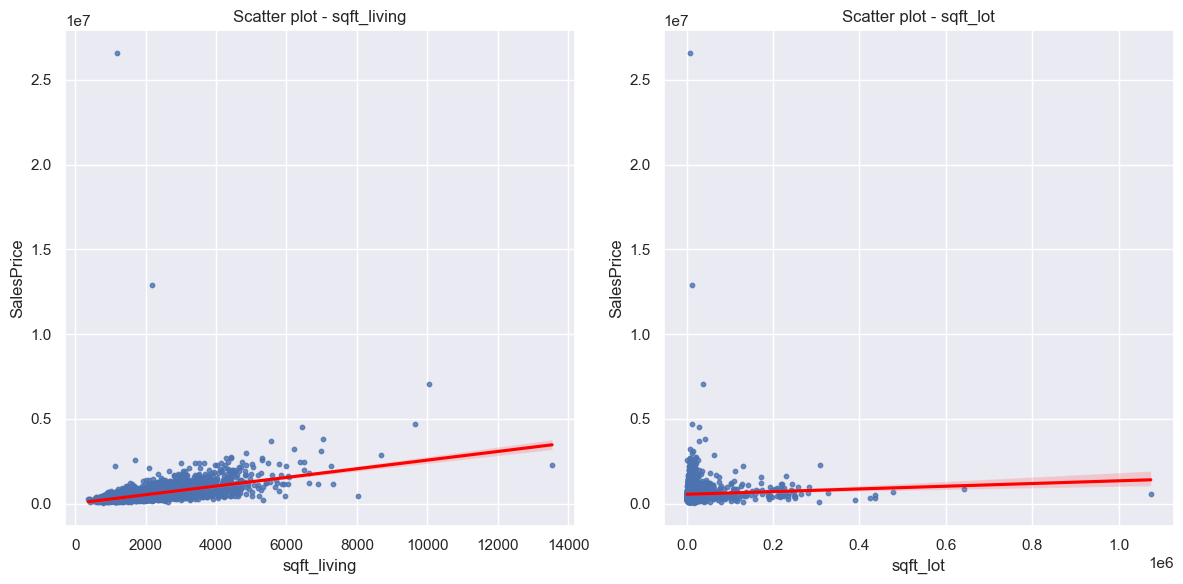

In [161]:
# Displaying the output with the Linear Regression Line
selected_features = ['sqft_living', 'sqft_lot']

sns.set(style="darkgrid")

fig, axes = plt.subplots(nrows=1, ncols=len(selected_features), figsize=(12, 6))

for i, feature in enumerate(selected_features):
    sns.regplot(x=feature, y='SalesPrice', data=house_price, ax=axes[i], scatter_kws={'s': 10}, line_kws={'color': 'red'})
    axes[i].set_title(f'Scatter plot - {feature}')


plt.tight_layout()
plt.show()



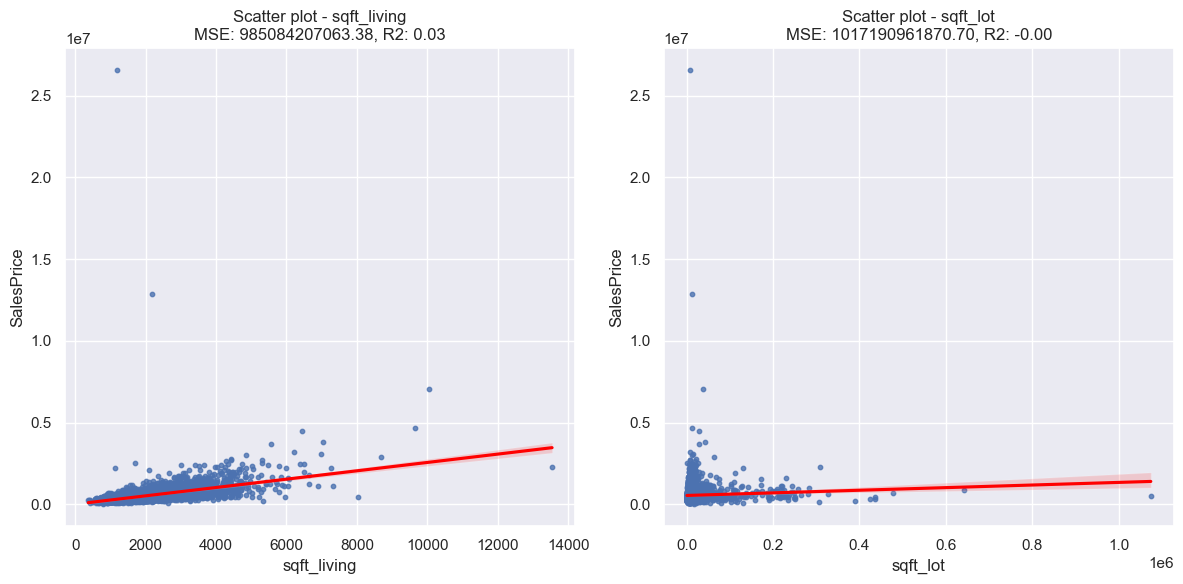

In [165]:
selected_features = ['sqft_living', 'sqft_lot']

X = house_price[selected_features]
y = house_price['SalesPrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()

fig, axes = plt.subplots(nrows=1, ncols=len(selected_features), figsize=(12, 6))

# Including R2 and MSE
for i, feature in enumerate(selected_features):
  
    model.fit(X_train[[feature]], y_train)
    y_pred = model.predict(X_test[[feature]])

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    sns.regplot(x=feature, y='SalesPrice', data=house_price, ax=axes[i], scatter_kws={'s': 10}, line_kws={'color': 'red'})
    axes[i].set_title(f'Scatter plot - {feature}\nMSE: {mse:.2f}, R2: {r2:.2f}')


plt.tight_layout()
plt.show()


**Observation:**

 - The models are inaccurate as the R2 value are very low and very high MSE for both the features.

## Polynomial Regression

## 2.13. Use a polynomial feature's function and implement a polynomial regression model of degree 2 for the features sqft_lot and the target variable

In [187]:
#input
X = house_price[['sqft_lot']]

#output
y = house_price[['SalesPrice']]

In [188]:
# Taking polynomial with degree 2
polynomial_features = PolynomialFeatures(degree = 2, include_bias = False)
Xp = polynomial_features.fit_transform(X)

In [189]:
pr = LinearRegression()
pr.fit(Xp,y)

LinearRegression()

In [190]:
#B1*

pr.coef_

print("B1* : ", pr.coef_)

#B0*

pr.intercept_

print("B0* : ", pr.intercept_)

B1* :  [[ 1.67763364e+00 -2.01883888e-06]]
B0* :  [535043.59801874]


## 2.14. Print R-squared (R2) score.

In [191]:
R2_Poly_regression = r2_score(y,pr.predict(Xp))
print("R2 : ",R2_Poly_regression)

R2 :  0.0046264126724733234


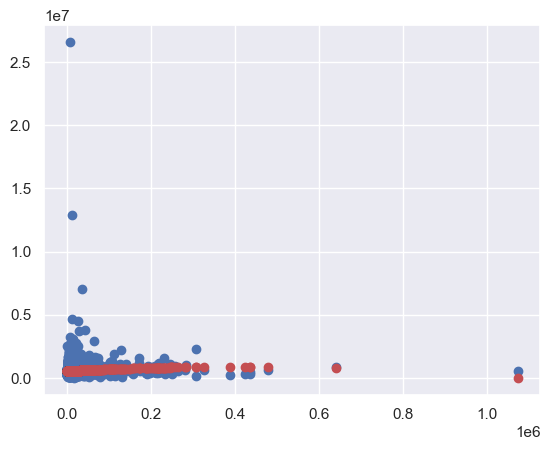

In [192]:
plt.scatter(X,y)
plt.scatter(X,pr.predict(Xp), c='r')

## 2.15.Experiment with different polynomial degrees and find the best fit as per your perspective.

We will build polynomial model with degree 10 and check R2 score

In [193]:
# Taking polynomial with degree 10
polynomial_features = PolynomialFeatures(degree = 10, include_bias = False)
Xp = polynomial_features.fit_transform(X)

In [194]:
pr = LinearRegression()
pr.fit(Xp,y)

LinearRegression()

In [195]:
#B1*

pr.coef_

print("B1* : ", pr.coef_)

#B0*

pr.intercept_

print("B0* : ", pr.intercept_)

B1* :  [[-3.98285295e-79 -1.23356599e-41  1.32020197e-49  4.07831529e-56
  -1.05713981e-56 -3.74777302e-51 -1.15119376e-45 -2.43145444e-40
   6.45260690e-46 -3.89977836e-52]]
B0* :  [556919.06462332]


In [196]:
# R2 score
R2_Poly_regression = r2_score(y,pr.predict(Xp))
print("R2 : ",R2_Poly_regression)

R2 :  6.678120856384862e-05


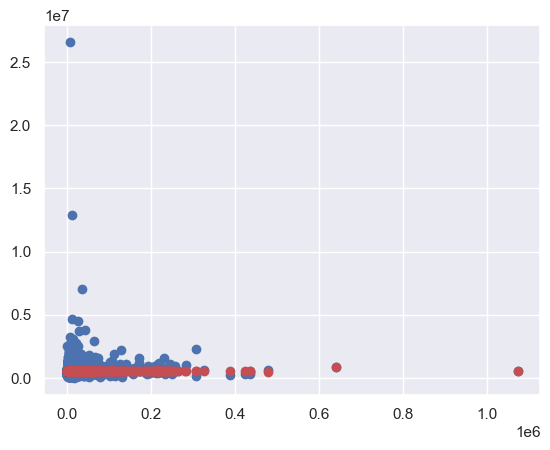

In [197]:
plt.scatter(X,y)
plt.scatter(X,pr.predict(Xp), c='r')

We will build polynomial model with degree 20 and check R2 score

In [198]:
# Taking polynomial with degree 20
polynomial_features = PolynomialFeatures(degree = 20, include_bias = False)
Xp = polynomial_features.fit_transform(X)

In [199]:
pr = LinearRegression()
pr.fit(Xp,y)

LinearRegression()

In [200]:
#B1*

pr.coef_

print("B1* : ", pr.coef_)

#B0*

pr.intercept_

print("B0* : ", pr.intercept_)

B1* :  [[ 2.45410739e-209 -1.68034319e-111  3.87259191e-121  1.35799963e-191
  -1.04966814e-140  1.46636945e-149  2.97856295e-150  1.74804861e-156
   9.32292663e-156  3.45736381e-157  2.90579988e-151  1.85087972e-145
   1.17361278e-139  7.38400458e-134  4.58307558e-128  2.77593220e-122
   1.60514063e-116  8.41468292e-111  3.37872119e-105 -3.14528789e-111]]
B0* :  [556855.14302388]


In [201]:
# R2 score
R2_Poly_regression = r2_score(y,pr.predict(Xp))
print("R2 : ",R2_Poly_regression)

R2 :  5.950238550533893e-05


## 2.16. Plot the polynomial regression curve along with the actual data points

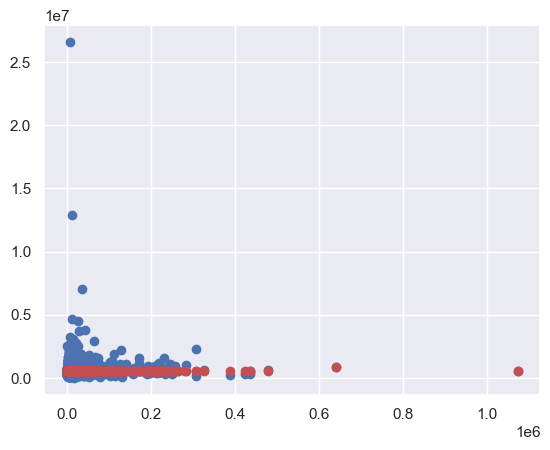

In [202]:
#Plot with Polynomial regression of degree 20

plt.scatter(X,y)
plt.scatter(X,pr.predict(Xp), c='r')

## RANSAC (Robust Regression)

## 2.19. Apply RANSAC (Random Sample Consensus) to fit a robust linear regression model to the features sqft_lot and the target variable.

In [ ]:
from sklearn.linear_model import RANSACRegressor

In [ ]:
#input
X = house_price[['sqft_lot']]

#output
y = house_price[['SalesPrice']]

In [ ]:
ransac = RANSACRegressor(LinearRegression(), max_trials=100, min_samples=50)
ransac.fit(X, y)

RANSACRegressor(estimator=LinearRegression(), min_samples=50)

## 2.20. Print coef and intercept. Visualize plot wrt inliers and outliers.

In [ ]:
#B1*
print("B1* : ", ransac.estimator_.coef_)

#B0*
print("B0* : ",ransac.estimator_.intercept_)

B1* :  [[0.46770074]]
B0* :  [441743.92290971]


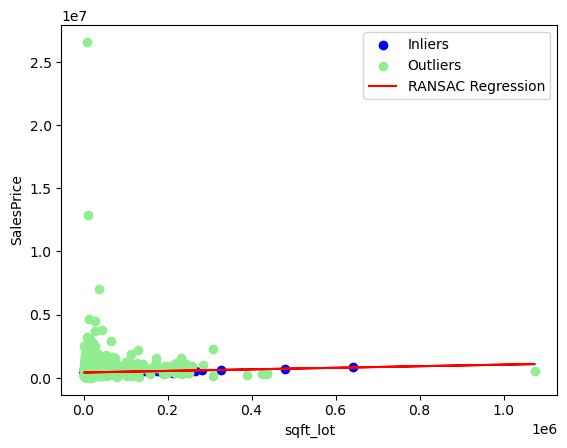

In [ ]:
# Visualize

#input
X = house_price[['sqft_lot']]

#output
y = house_price[['SalesPrice']]

# RANSAC model
ransac = RANSACRegressor(LinearRegression(), max_trials=100, min_samples=50)
ransac.fit(X, y)

# Obtain inlier and outlier masks
inlier_mask = ransac.inlier_mask_
outlier_mask = np.logical_not(inlier_mask)

# Plotting
plt.scatter(X[inlier_mask], y[inlier_mask], c='b', label='Inliers')
plt.scatter(X[outlier_mask], y[outlier_mask], c='lightgreen', label='Outliers')
plt.plot(X, ransac.predict(X), c='r', label='RANSAC Regression')
plt.xlabel('sqft_lot')
plt.ylabel('SalesPrice')
plt.legend()
plt.show()

## 2.21. Print R-squared (R2) score with and without inliers.

In [ ]:
# R-squared score with inliers
R2_RANSAC = r2_score(y,ransac.predict(X))
print("R2 : ",R2_RANSAC )

R2 :  -0.04422492535050959


In [ ]:
# R-squared score without inliers
R2_RANSAC = r2_score(y[inlier_mask],ransac.predict(X[inlier_mask]))
print("R2 : ",R2_RANSAC )

R2 :  0.04610825765025062


## Model Evaluation

## 2.22. Compare the results and discuss which model(s) best-predicted housing prices.

A comparison between the various models using Linear Regression (Single Variable), Linear Regression (Multivariate), Polynomial Regression and RANSAC (Robust Regression) is given below based on their respective R2 values.Typically we have to choose a high R-squared value which predicts the accuracy of the model. A higher R2 value indicates a higher accuracy of the model.



**Obtained R2 for respective regression type:**
- Linear Regression (Single Variable) : 0.002 (for feature sqft_lot)
- Linear Regression (Multivariate) : 0.00 (for feature sqft_lot)
- Polynomial Regression : 0.002 (Degree=20)
- RANSAC (Robust) Regression : 0.046 (without inliers)



From the results obtained through various regression models, we can observe that the R2 value is the highest for RANSAC regression suggesting that it provides a better accuracy model when compared to all other regression techniques. 


# DATA220_Section23_Math Method for Data Analysis
## Pair Programming Lab2


### Aiswarya Raghavadesikan (014574599) 
### Aryama Ray (017401124)

## Question 3  : Life Expectancy Prediction

### Importing the Libraries

In [559]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 3.1. Load the dataset and present the statistics of data

### Loading Life_expectancy  dataset

In [560]:
life_exp= pd.read_csv('LifeExpectancy.csv')

### Checking the head and tail of the loaded dataset

In [561]:
life_exp.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [562]:
life_exp.tail()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.0,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.0,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.0,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.0,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8
2937,Zimbabwe,2000,Developing,46.0,665.0,24,1.68,0.0,79.0,1483,...,78.0,7.10,78.0,43.5,547.358878,12222251.0,11.0,11.2,0.434,9.8


### Checking the shape of the dataset

In [563]:
life_exp.shape

(2938, 22)

### Checking the columns of the dataset

In [564]:
life_exp.columns

Index(['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles', 'BMI', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria', ' HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years',
       'thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='object')

### Checking the datatypes of each columns in this dataset

In [565]:
life_exp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2938 non-null   float64
 4   Adult Mortality                  2938 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2938 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2938 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2938 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

### Summary statistics of Life expectancy dataset

In [566]:
life_exp.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2.938000e+03,2938.000000,2938.000000,2938.000000,2938.000000
mean,2007.518720,69.234717,164.725664,30.303948,4.546875,738.251295,83.022124,2419.592240,38.381178,42.035739,82.617767,5.924098,82.393125,1.742103,6611.523863,1.023085e+07,4.821886,4.852144,0.630362,12.009837
std,4.613841,9.509115,124.086215,117.926501,3.921946,1987.914858,22.996984,11467.272489,19.935375,160.445548,23.367166,2.400770,23.655562,5.077785,13296.603449,5.402242e+07,4.397621,4.485854,0.205140,3.265139
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.370000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.200000,74.000000,0.000000,1.092500,4.685343,82.000000,0.000000,19.400000,0.000000,78.000000,4.370000,78.000000,0.100000,580.486996,4.189172e+05,1.600000,1.600000,0.504250,10.300000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.755000,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.600000,227.000000,22.000000,7.390000,441.534144,96.000000,360.250000,56.100000,28.000000,97.000000,7.330000,97.000000,0.800000,4779.405190,4.584371e+06,7.100000,7.200000,0.772000,14.100000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.600000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


## 3.2 Identify and specify the target variable from the dataset

        Life Expectancy dataset has 22 fields and 2938 records from 193 countries. The dataset is a collection of data about various factors like- 'Adult Mortality','infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B','Measles', 'BMI', 'under-five deaths ', 'Polio', 'Total expenditure' etc collected over few years from different countries.  
       
       These attributes might contribute towards determining the 'Life expectancy' index of a country. So, the target variable here is 'Life expectancy' attribute.

In [567]:
life_exp['Life expectancy'].describe()

count    2938.000000
mean       69.234717
std         9.509115
min        36.300000
25%        63.200000
50%        72.100000
75%        75.600000
max        89.000000
Name: Life expectancy, dtype: float64

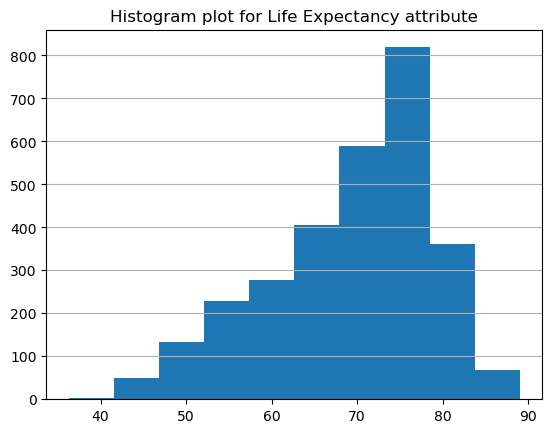

In [568]:
plt.title('Histogram plot for Life Expectancy attribute')
plt.hist(life_exp['Life expectancy'])
plt.grid(axis='y')

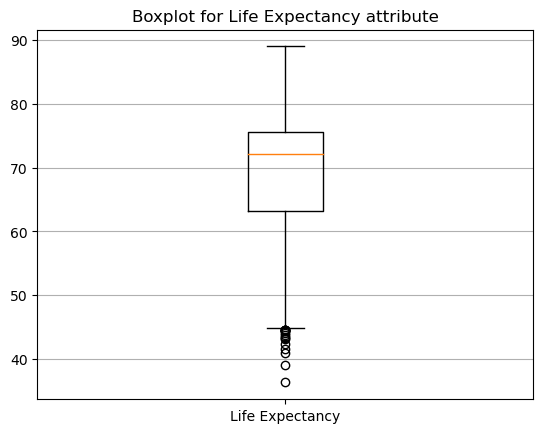

In [569]:
plt.title('Boxplot for Life Expectancy attribute')
plt.boxplot(life_exp['Life expectancy'],labels=['Life Expectancy'])
plt.grid(axis='y')

The values of Life Expectancy attributes ranges from 36.3 to 89 with standard deviation of 9.5 approx. The bosplot of this attribute shows that there are some outliers below  Q1(25%)-1.5IQR point in the graph and it is responsible for bringing down the mean value from the median point of this attribute value.

Also, the histogram plot is telling that there exist highest number of data points with life expectancy value between the range of 70 to 80. 

## 3.3 Categorize the columns into categorical and continuous

In [570]:
life_exp.dtypes

Country                             object
Year                                 int64
Status                              object
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
BMI                                float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
 HIV/AIDS                          float64
GDP                                float64
Population                         float64
thinness  1-19 years               float64
thinness 5-9 years                 float64
Income composition of resources    float64
Schooling                          float64
dtype: object

So, among 22 columns in Life expectancy dataset, Country and  Status are categorical variables and rest of the columns are continous variables.

In [571]:
cat_var=life_exp[['Country','Status']]
cat_var.columns

Index(['Country', 'Status'], dtype='object')

#### Categorical variables in the dataset

In [572]:
cat_var_col_array=cat_var.columns.tolist()
cat_var_col_array

['Country', 'Status']

#### Continuous variables in the dataset

In [573]:

cont_var_col_array=life_exp.loc[:, ~life_exp.columns.isin(cat_var_col_array)].columns.tolist()
cont_var_col_array

['Year',
 'Life expectancy',
 'Adult Mortality',
 'infant deaths',
 'Alcohol',
 'percentage expenditure',
 'Hepatitis B',
 'Measles',
 'BMI',
 'under-five deaths ',
 'Polio',
 'Total expenditure',
 'Diphtheria',
 ' HIV/AIDS',
 'GDP',
 'Population',
 'thinness  1-19 years',
 'thinness 5-9 years',
 'Income composition of resources',
 'Schooling']

## 3.4 Identify the unique values from each column.

### Checking the categorical variable - Status

In [574]:
life_exp.Status.unique()

array(['Developing', 'Developed'], dtype=object)

  -  Status is categorical variable and has 2 unique values - Developing and Developed.

### Checking the categorical variable - Country

In [575]:
life_exp.Country.unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia',
       'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan',
       'Bolivia (Plurinational State of)', 'Bosnia and Herzegovina',
       'Botswana', 'Brazil', 'Brunei Darussalam', 'Bulgaria',
       'Burkina Faso', 'Burundi', "Côte d'Ivoire", 'Cabo Verde',
       'Cambodia', 'Cameroon', 'Canada', 'Central African Republic',
       'Chad', 'Chile', 'China', 'Colombia', 'Comoros', 'Congo',
       'Cook Islands', 'Costa Rica', 'Croatia', 'Cuba', 'Cyprus',
       'Czechia', "Democratic People's Republic of Korea",
       'Democratic Republic of the Congo', 'Denmark', 'Djibouti',
       'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia',
       'Ethiopia', 'Fiji', 'Finland', 'France', 'Gabon', 'Gambia',
       'Georgia', 'Germany'

In [576]:
print( 'We have data from %d number of countries' % len(life_exp.Country.unique()))

We have data from 193 number of countries


 -   Country is another categorical variable in the dataset with 193 unique values. So, we have data from 193 countries.

## 3.5. Identify the Missing values and compute the missing values with mean, median or mode based on their categories. Also explain why and how you performed each imputation.

#### Checking null values in each columns


In [577]:
life_exp.isnull().sum()

Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
BMI                                0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
 HIV/AIDS                          0
GDP                                0
Population                         0
thinness  1-19 years               0
thinness 5-9 years                 0
Income composition of resources    0
Schooling                          0
dtype: int64

 - life expectancy dataset does not have any null values in any columns. 
 - So, we will check the dataset for the presensence of zero values in any of these columns

#### Checking zero values in each column except taget variable 

In [578]:

Country_zero_cnt= (life_exp['Country'] == 0).sum()
print('Country_zero_cnt :',Country_zero_cnt)

Year_zero_cnt= (life_exp['Year'] == 0).sum()
print('Year_zero_cnt :',Year_zero_cnt)

Status_zero_cnt= (life_exp['Status'] == 0).sum()
print('Status_zero_cnt :',Status_zero_cnt)

Life_expectancy_zero_cnt= (life_exp['Life expectancy'] == 0).sum()
print('Life expectancy_zero_cnt :',Life_expectancy_zero_cnt)

Adult_Mortality_zero_cnt= (life_exp['Adult Mortality'] == 0).sum()
print('Adult_Mortality_zero_cnt :',Adult_Mortality_zero_cnt)

infant_deaths_zero_cnt= (life_exp['infant deaths'] == 0).sum()
print('infant_deaths_zero_cnt :',infant_deaths_zero_cnt)

Alcohol_zero_cnt= (life_exp['Alcohol'] == 0).sum()
print('Alcohol_zero_cnt :',Alcohol_zero_cnt)

percentage_expenditure_zero_cnt= (life_exp['percentage expenditure'] == 0).sum()
print('percentage_expenditure_zero_cnt :',percentage_expenditure_zero_cnt)

Hepatitis_B_zero_cnt= (life_exp['Hepatitis B'] == 0).sum()
print('Hepatitis_B_zero_cnt :',Hepatitis_B_zero_cnt)

Measles_zero_cnt= (life_exp['Measles'] == 0).sum()
print('Measles_zero_cnt :',Measles_zero_cnt)

BMI_zero_cnt= (life_exp['BMI'] == 0).sum()
print('BMI_zero_cnt :',BMI_zero_cnt)

under_five_deaths_zero_cnt=(life_exp['under-five deaths '] == 0).sum()
print('under_five_deaths_zero_cnt :',under_five_deaths_zero_cnt)

Polio_zero_cnt= (life_exp['Polio'] == 0).sum()
print('Polio_zero_cnt :',Polio_zero_cnt)

Total_expenditure_zero_cnt= (life_exp['Total expenditure'] == 0).sum()
print('Total_expenditure_zero_cnt :',Total_expenditure_zero_cnt)

Diphtheria_zero_cnt= (life_exp['Diphtheria'] == 0).sum()
print('Diphtheria_zero_cnt :',Diphtheria_zero_cnt)

HIV_AIDS_zero_cnt= (life_exp[' HIV/AIDS'] == 0).sum()
print('HIV_AIDS_zero_cnt :',HIV_AIDS_zero_cnt)

GDP_zero_cnt= (life_exp['GDP'] == 0).sum()
print('GDP_zero_cnt :',GDP_zero_cnt)

Population_zero_cnt= (life_exp['Population'] == 0).sum()
print('Population_zero_cnt :',Population_zero_cnt)

thinness_1_19_years_zero_cnt= (life_exp['thinness  1-19 years'] == 0).sum()
print('thinness_1_19_years_zero_cnt :',thinness_1_19_years_zero_cnt)

thinness_5_9_years_zero_cnt= (life_exp['thinness 5-9 years'] == 0).sum()
print('thinness_5_9_years_zero_cnt :',thinness_5_9_years_zero_cnt)

Income_composition_of_resources_zero_cnt= (life_exp['Income composition of resources'] == 0).sum()
print('Income_composition_of_resources_zero_cnt :',Income_composition_of_resources_zero_cnt)

Schooling_zero_cnt= (life_exp['Schooling'] == 0).sum()
print('Schooling_zero_cnt :',Schooling_zero_cnt)

Country_zero_cnt : 0
Year_zero_cnt : 0
Status_zero_cnt : 0
Life expectancy_zero_cnt : 0
Adult_Mortality_zero_cnt : 0
infant_deaths_zero_cnt : 848
Alcohol_zero_cnt : 0
percentage_expenditure_zero_cnt : 611
Hepatitis_B_zero_cnt : 0
Measles_zero_cnt : 983
BMI_zero_cnt : 0
under_five_deaths_zero_cnt : 785
Polio_zero_cnt : 0
Total_expenditure_zero_cnt : 0
Diphtheria_zero_cnt : 0
HIV_AIDS_zero_cnt : 0
GDP_zero_cnt : 0
Population_zero_cnt : 0
thinness_1_19_years_zero_cnt : 0
thinness_5_9_years_zero_cnt : 0
Income_composition_of_resources_zero_cnt : 130
Schooling_zero_cnt : 28


Following attributes are having zero value fields:
 -  infant_deaths_zero_cnt, 
 -  percentage_expenditure_zero_cnt, 
 -  Measles_zero_cnt, 
 -  under_five_deaths_zero_cnt, 
 -  Income_composition_of_resources_zero_cnt,
 -  Schooling_zero_cnt fields 
 
 We will replace all these zero values with null values.


In [579]:
life_exp['infant deaths'] = life_exp['infant deaths'].replace(0,np.nan)
life_exp['percentage expenditure'] = life_exp['percentage expenditure'].replace(0,np.nan)
life_exp['Measles'] = life_exp['Measles'].replace(0,np.nan)
life_exp['under-five deaths '] = life_exp['under-five deaths '].replace(0,np.nan)
life_exp['Income composition of resources'] = life_exp['Income composition of resources'].replace(0,np.nan)
life_exp['Schooling'] = life_exp['Schooling'].replace(0,np.nan)

####  Checking null values in each columns

In [580]:
life_exp.isnull().sum()

Country                              0
Year                                 0
Status                               0
Life expectancy                      0
Adult Mortality                      0
infant deaths                      848
Alcohol                              0
percentage expenditure             611
Hepatitis B                          0
Measles                            983
BMI                                  0
under-five deaths                  785
Polio                                0
Total expenditure                    0
Diphtheria                           0
 HIV/AIDS                            0
GDP                                  0
Population                           0
thinness  1-19 years                 0
thinness 5-9 years                   0
Income composition of resources    130
Schooling                           28
dtype: int64

    -   infant deaths and under-five deaths field values are having  zero for multiple developed and deveoping countries for consecutive years which is not quite convinvingly correct. So these fields need value imputation as the correct values are missing here.
    -   percentage expenditure field is zero for few countries even though they have total expenditure as not null. So this field needs imputation.
    
    -   Since all of these fields are continuous fields, we will be imputing all these null values with the corresponding median values of the attribute. Thus, distribution of these continuous attribute will remain unchanged.

In [581]:
life_exp['infant deaths'].fillna(value = life_exp['infant deaths'].median(), inplace = True)
life_exp['percentage expenditure'].fillna(value = life_exp['percentage expenditure'].median(), inplace = True)
life_exp['Measles'].fillna(value = life_exp['Measles'].median(), inplace = True)
life_exp['under-five deaths '].fillna(value = life_exp['under-five deaths '].median(), inplace = True)
life_exp['Income composition of resources'].fillna(value = life_exp['Income composition of resources'].median(), inplace = True)
life_exp['Schooling'].fillna(value = life_exp['Schooling'].median(), inplace = True)

#### Checking null values in each columns after median value imputation

In [582]:
life_exp.isnull().sum()

Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
BMI                                0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
 HIV/AIDS                          0
GDP                                0
Population                         0
thinness  1-19 years               0
thinness 5-9 years                 0
Income composition of resources    0
Schooling                          0
dtype: int64

## 3.6 Check for the outliers in each column using the IQR method

 - A data point is called outlier when it is outside the range of 1.5 times the IQR below the 25th percentile or above the 75th percentile. 
 - Here, we will calculate the 25th and 75th percentiles of the dataset and then calculate the IQR to identify outliers.
 - We will find out outlier data from all the cotinuous variable fields


#### Continuous variables are fere:

In [583]:
cont_var_col_array

['Year',
 'Life expectancy',
 'Adult Mortality',
 'infant deaths',
 'Alcohol',
 'percentage expenditure',
 'Hepatitis B',
 'Measles',
 'BMI',
 'under-five deaths ',
 'Polio',
 'Total expenditure',
 'Diphtheria',
 ' HIV/AIDS',
 'GDP',
 'Population',
 'thinness  1-19 years',
 'thinness 5-9 years',
 'Income composition of resources',
 'Schooling']

In [584]:
Q1 = life_exp['Adult Mortality'].quantile(0.25)
Q3 = life_exp['Adult Mortality'].quantile(0.75)
IQR = Q3 - Q1

# identify outliers
threshold = 1.5
outliers = life_exp[(life_exp['Adult Mortality'] < Q1 - threshold * IQR) | (life_exp['Adult Mortality'] > Q3 + threshold * IQR)]
outliers

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
345,Botswana,2006,Developing,54.8,491.0,2.0,6.45,76.318679,93.0,6.0,...,96.0,4.93,96.0,14.4,5374.554867,1884238.0,9.6,9.4,0.610,11.9
346,Botswana,2005,Developing,51.7,566.0,2.0,6.37,629.842564,92.0,5.0,...,96.0,5.62,96.0,20.6,5351.253732,1855852.0,1.0,9.9,0.593,11.9
347,Botswana,2004,Developing,48.1,652.0,2.0,4.90,469.582390,91.0,1.0,...,96.0,5.56,96.0,28.4,4896.583835,182933.0,1.5,1.4,0.580,11.8
348,Botswana,2003,Developing,46.4,693.0,2.0,5.51,299.367125,9.0,59.0,...,96.0,4.65,96.0,31.9,4163.659600,184339.0,1.9,1.8,0.567,11.8
349,Botswana,2002,Developing,46.0,699.0,2.0,6.41,6.330007,88.0,7.0,...,97.0,6.47,97.0,34.6,355.618382,1779953.0,11.4,11.3,0.558,11.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2932,Zimbabwe,2005,Developing,44.6,717.0,28.0,4.14,8.717409,65.0,420.0,...,69.0,6.44,68.0,30.3,444.765750,129432.0,9.0,9.0,0.406,9.3
2933,Zimbabwe,2004,Developing,44.3,723.0,27.0,4.36,155.195208,68.0,31.0,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26.0,4.06,155.195208,7.0,998.0,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2936,Zimbabwe,2001,Developing,45.3,686.0,25.0,1.72,155.195208,76.0,529.0,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


#### User defined function to find out outlier data for the given attribute from the dataset using IQR

In [585]:
def find_outlier_subset(df,column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

# identify outliers
    threshold = 1.5
    outlier_subset = df[(df[column] < Q1 - threshold * IQR) | (df[column] > Q3 + threshold * IQR)]
    return outlier_subset[column]

#### Outlier data for Life Expectancy

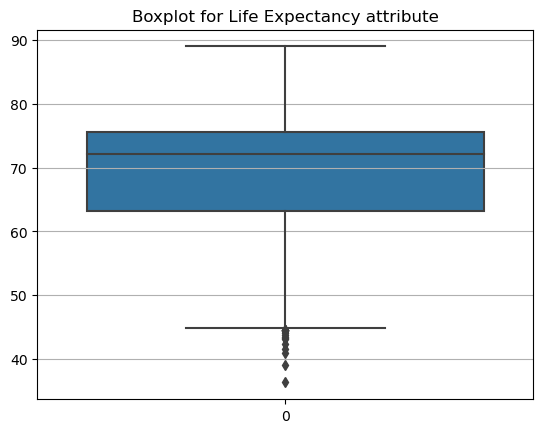

In [586]:
plt.title('Boxplot for Life Expectancy attribute')
sns.boxplot(life_exp['Life expectancy'],labels=['Life Expectancy'])
plt.grid(axis='y')

In [587]:
find_outlier_subset(life_exp,'Life expectancy')

1127    36.3
1484    44.5
1582    44.6
1583    44.0
1584    43.5
1585    43.1
2306    44.3
2307    43.3
2308    42.3
2309    41.5
2311    41.0
2312    39.0
2920    44.6
2921    43.8
2932    44.6
2933    44.3
2934    44.5
Name: Life expectancy, dtype: float64

#### Outlier data for Adult Mortality

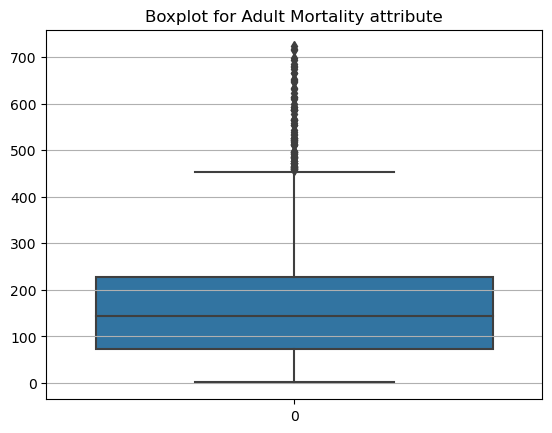

In [588]:
plt.title('Boxplot for Adult Mortality attribute')
sns.boxplot(life_exp['Adult Mortality'],labels=['Adult Mortality'])
plt.grid(axis='y')

In [589]:
find_outlier_subset(life_exp,'Adult Mortality')

345     491.0
346     566.0
347     652.0
348     693.0
349     699.0
        ...  
2932    717.0
2933    723.0
2934    715.0
2936    686.0
2937    665.0
Name: Adult Mortality, Length: 86, dtype: float64

#### Outlier data for Infant deaths attribute

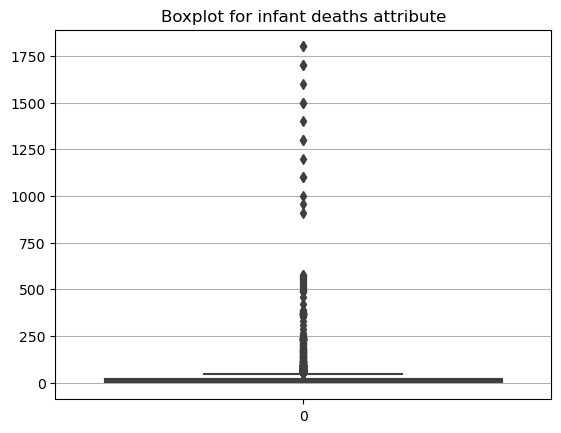

In [590]:
plt.title('Boxplot for infant deaths attribute')
sns.boxplot(life_exp['infant deaths'],labels=['infant deaths'])
plt.grid(axis='y')

In [591]:
find_outlier_subset(life_exp,'infant deaths')

0        62.0
1        64.0
2        66.0
3        69.0
4        71.0
        ...  
2789    100.0
2790    103.0
2791    106.0
2792    110.0
2793    114.0
Name: infant deaths, Length: 374, dtype: float64

In [592]:
#### Outlier data for Alcohol attribute

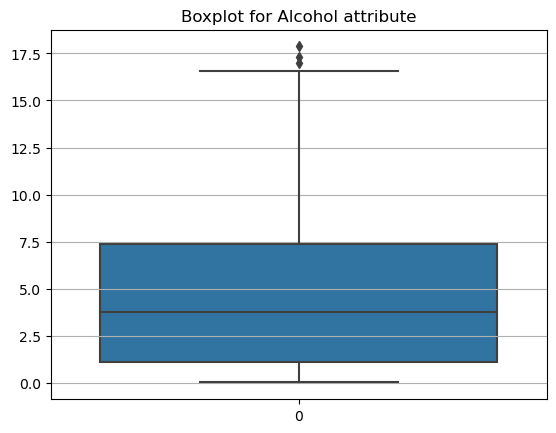

In [593]:
plt.title('Boxplot for Alcohol attribute')
sns.boxplot(life_exp['Alcohol'],labels=['Alcohol'])
plt.grid(axis='y')

In [594]:
find_outlier_subset(life_exp,'Alcohol')

228    17.31
873    16.99
874    17.87
Name: Alcohol, dtype: float64

In [595]:
#### Outlier data for percentage expenditure attribute

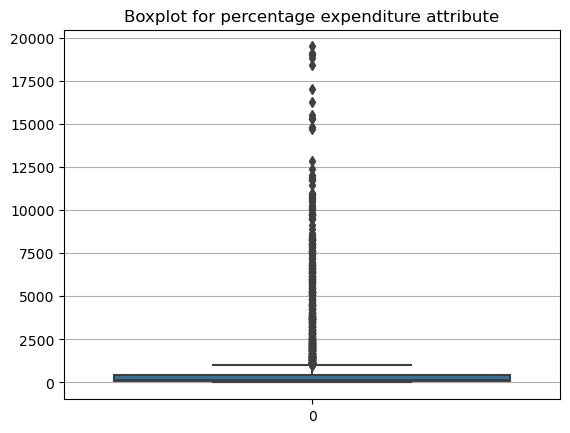

In [596]:
plt.title('Boxplot for percentage expenditure attribute')
sns.boxplot(life_exp['percentage expenditure'],labels=['percentage expenditure'])
plt.grid(axis='y')

In [597]:
find_outlier_subset(life_exp,'percentage expenditure')

65      2422.999774
66      1991.430372
67      2156.229842
68      1810.875316
69      1983.956937
           ...     
2757    2972.448675
2759    2598.842827
2815    2331.532804
2816    1871.736563
2819    1712.225506
Name: percentage expenditure, Length: 407, dtype: float64

#### Outlier data for Hepatitis B attribute

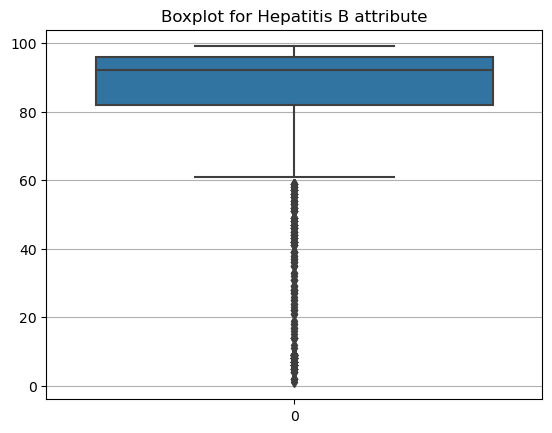

In [598]:
plt.title('Boxplot for Hepatitis B attribute')
sns.boxplot(life_exp['Hepatitis B'],labels=['Hepatitis B'])
plt.grid(axis='y')

In [599]:
find_outlier_subset(life_exp,'Hepatitis B')

40       9.0
41       8.0
87       9.0
111     55.0
142     44.0
        ... 
2905    14.0
2906     9.0
2914     8.0
2927     9.0
2934     7.0
Name: Hepatitis B, Length: 322, dtype: float64

#### Outlier data for Measles attribute

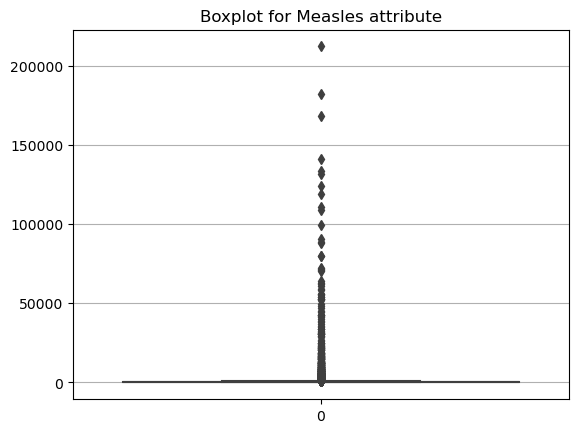

In [600]:
plt.title('Boxplot for Measles attribute')
sns.boxplot(life_exp['Measles'],labels=['Measles'])
plt.grid(axis='y')

In [601]:
find_outlier_subset(life_exp,'Measles')

0        1154.0
3        2787.0
4        3013.0
5        1989.0
6        2861.0
         ...   
2921    30930.0
2927     9696.0
2928      853.0
2934      998.0
2937     1483.0
Name: Measles, Length: 558, dtype: float64

#### Outlier data for BMI attribute

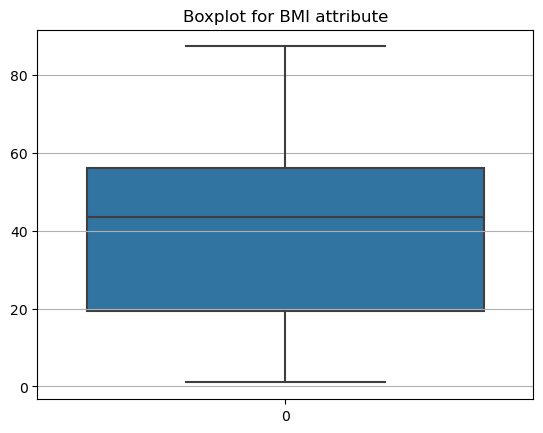

In [602]:
plt.title('Boxplot for BMI attribute')
sns.boxplot(life_exp['BMI'],labels=['BMI'])
plt.grid(axis='y')

In [603]:
find_outlier_subset(life_exp,'BMI')

Series([], Name: BMI, dtype: float64)

In [604]:
#### Outlier data for under-five deaths  attribute

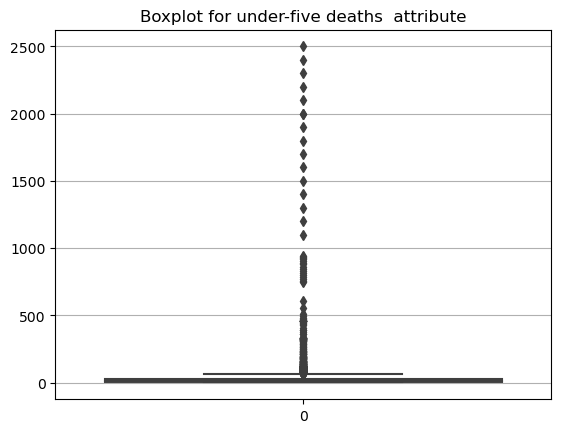

In [605]:
plt.title('Boxplot for under-five deaths  attribute')
sns.boxplot(life_exp['under-five deaths '],labels=['under-five deaths '])
plt.grid(axis='y')

In [606]:
find_outlier_subset(life_exp,'under-five deaths ')

0        83.0
1        86.0
2        89.0
3        93.0
4        97.0
        ...  
2793    181.0
2905     66.0
2919     66.0
2920     70.0
2921     72.0
Name: under-five deaths , Length: 418, dtype: float64

In [607]:
#### Outlier data for Polio  attribute

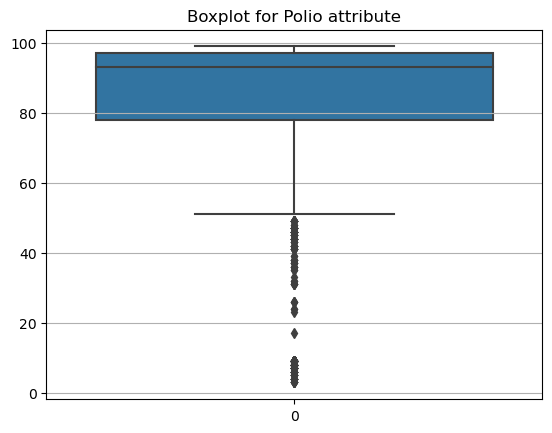

In [608]:
plt.title('Boxplot for Polio attribute')
sns.boxplot(life_exp['Polio'],labels=['Polio'])
plt.grid(axis='y')

In [609]:
find_outlier_subset(life_exp,'Polio')

0        6.0
11       5.0
12      41.0
13      36.0
14      35.0
        ... 
2906     9.0
2909     7.0
2911     8.0
2913     9.0
2934     7.0
Name: Polio, Length: 279, dtype: float64

In [610]:
#### Outlier data for Total expenditure attribute

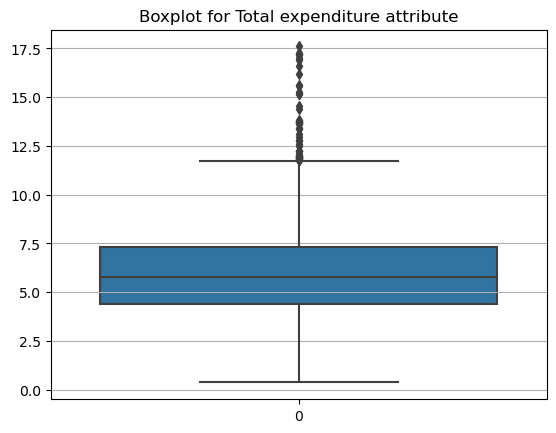

In [611]:
plt.title('Boxplot for Total expenditure attribute')
sns.boxplot(life_exp['Total expenditure'],labels=['Total expenditure'])
plt.grid(axis='y')

In [612]:
find_outlier_subset(life_exp,'Total expenditure')

663     11.78
742     11.80
1384    12.24
1385    12.23
1386    13.66
1478    11.79
1495    11.87
1496    14.39
1497    11.83
1573    12.60
1603    13.73
1650    17.24
1700    13.71
1701    13.38
1702    12.77
1703    13.76
1704    13.83
1705    13.44
1706    12.94
1707    11.99
1708    11.92
1709    12.11
2106    11.87
2108    12.80
2109    12.49
2298    11.90
2301    11.98
2303    13.13
2307    12.25
2310    11.96
2311    11.83
2312    13.63
2506    11.93
2507    11.97
2508    11.80
2713    16.61
2795    17.14
2796    16.90
2797    17.20
2798    17.60
2799    17.20
2800    17.00
2801    16.20
2802    15.57
2803    15.27
2804    15.15
2805    15.14
2806    15.60
2807    14.55
2808    13.73
2809    13.70
Name: Total expenditure, dtype: float64

In [613]:
#### Outlier data for Diphtheria attribute

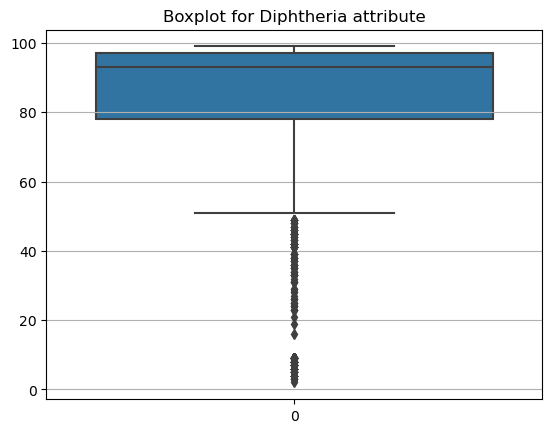

In [614]:
plt.title('Boxplot for Diphtheria attribute')
sns.boxplot(life_exp['Diphtheria'],labels=['Diphtheria'])
plt.grid(axis='y')

In [615]:
find_outlier_subset(life_exp,'Diphtheria')

11       5.0
12      41.0
13      36.0
14      33.0
15      24.0
        ... 
2865     5.0
2872     7.0
2906     9.0
2914     8.0
2931     7.0
Name: Diphtheria, Length: 298, dtype: float64

In [616]:
#### Outlier data for HIV/AIDS attribute

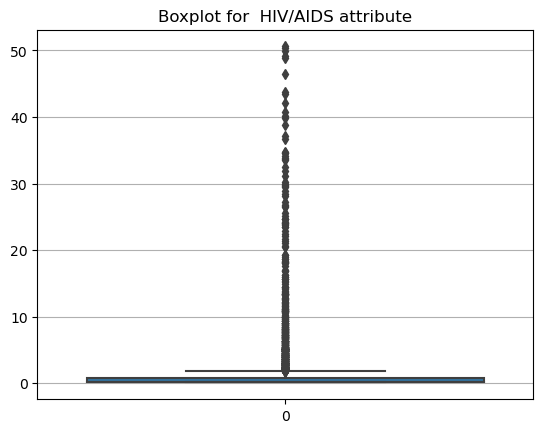

In [617]:
plt.title('Boxplot for  HIV/AIDS attribute')
sns.boxplot(life_exp[' HIV/AIDS'],labels=[' HIV/AIDS'])
plt.grid(axis='y')

In [618]:
find_outlier_subset(life_exp,' HIV/AIDS')

48       1.9
49       2.0
50       2.3
51       2.6
52       2.5
        ... 
2933    33.6
2934    36.7
2935    39.8
2936    42.1
2937    43.5
Name:  HIV/AIDS, Length: 542, dtype: float64

In [619]:
#### Outlier data for under-five deaths  attribute

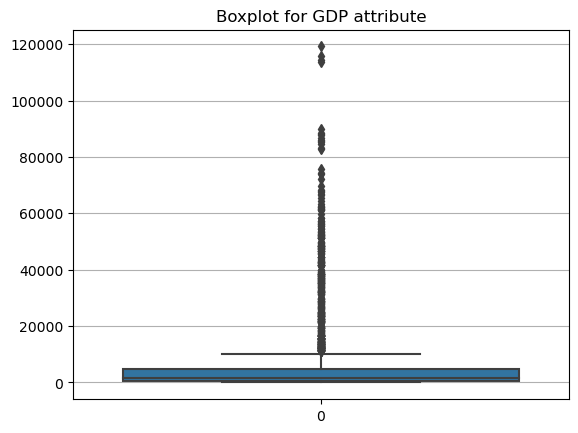

In [620]:
plt.title('Boxplot for GDP attribute')
sns.boxplot(life_exp['GDP'],labels=['GDP'])
plt.grid(axis='y')

In [621]:
find_outlier_subset(life_exp,'GDP')

64      13566.95410
65      12888.29667
66      12224.86416
67      12565.44197
68      11929.34991
           ...     
2810    15524.84247
2811    16737.89827
2812    16881.25680
2814    14166.49980
2815    11938.21200
Name: GDP, Length: 445, dtype: float64

In [622]:
#### Outlier data for Population attribute

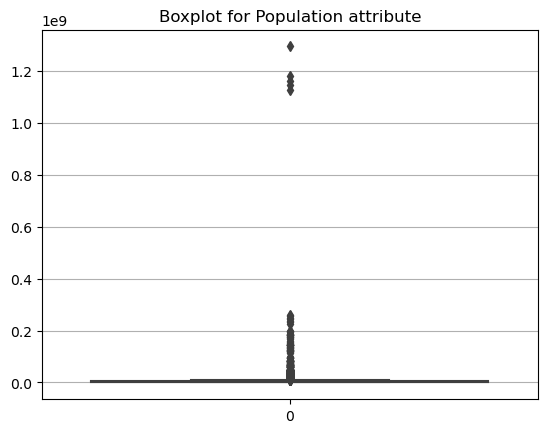

In [623]:
plt.title('Boxplot for Population attribute')
sns.boxplot(life_exp['Population'],labels=['Population'])
plt.grid(axis='y')

In [624]:
find_outlier_subset(life_exp,'Population')

0       33736494.0
2       31731688.0
8       26616792.0
11      24118979.0
13      21979923.0
           ...    
2931    13124267.0
2933    12777511.0
2934    12633897.0
2936    12366165.0
2937    12222251.0
Name: Population, Length: 452, dtype: float64

In [625]:
#### Outlier data for thinness  1-19 years attribute

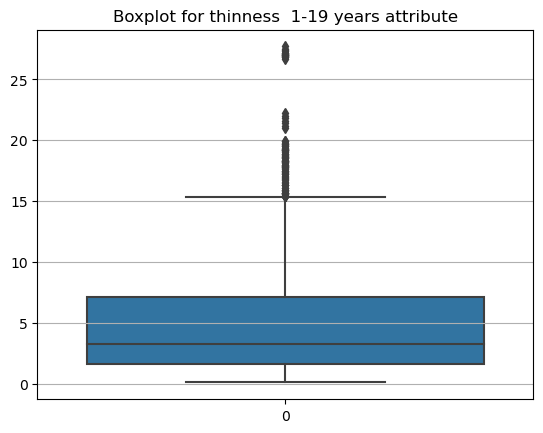

In [626]:
plt.title('Boxplot for thinness  1-19 years attribute')
sns.boxplot(life_exp['thinness  1-19 years'],labels=['thinness  1-19 years'])
plt.grid(axis='y')

In [627]:
find_outlier_subset(life_exp,'thinness  1-19 years')

0       17.2
1       17.5
2       17.7
3       17.9
4       18.2
        ... 
2885    15.4
2886    15.6
2887    15.6
2888    15.7
2889    15.8
Name: thinness  1-19 years, Length: 100, dtype: float64

In [628]:
#### Outlier data for thinness 5-9 years  attribute

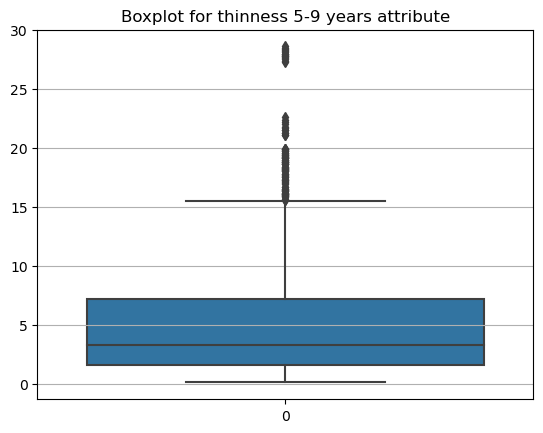

In [629]:
plt.title('Boxplot for thinness 5-9 years attribute')
sns.boxplot(life_exp['thinness 5-9 years'],labels=['thinness 5-9 years'])
plt.grid(axis='y')

In [630]:
find_outlier_subset(life_exp,'thinness 5-9 years')

0       17.3
1       17.5
2       17.7
3       18.0
4       18.2
        ... 
2885    16.1
2886    16.2
2887    16.3
2888    16.4
2889    16.4
Name: thinness 5-9 years, Length: 99, dtype: float64

In [631]:
#### Outlier data for Income composition of resources attribute

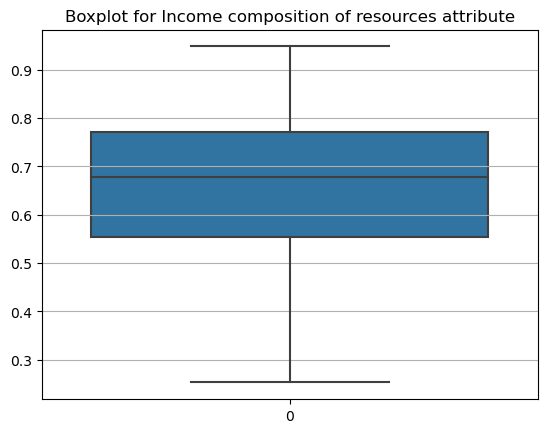

In [632]:
plt.title('Boxplot for Income composition of resources attribute')
sns.boxplot(life_exp['Income composition of resources'],labels=['Income composition of resources'])
plt.grid(axis='y')

In [633]:
find_outlier_subset(life_exp,'Income composition of resources')

Series([], Name: Income composition of resources, dtype: float64)

In [634]:
#### Outlier data for Schooling  attribute

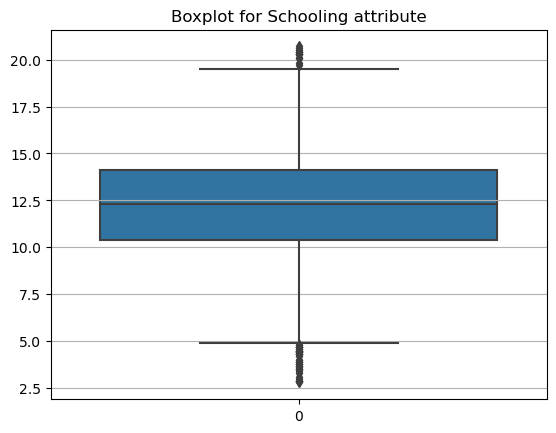

In [635]:
plt.title('Boxplot for Schooling attribute')
sns.boxplot(life_exp['Schooling'],labels=['Schooling'])
plt.grid(axis='y')

In [636]:
find_outlier_subset(life_exp,'Schooling')

63       4.6
112     20.4
113     20.4
114     20.3
115     20.1
116     19.8
121     20.3
122     20.3
123     20.7
124     20.6
125     20.1
126     20.5
127     20.4
409      4.7
410      4.3
411      3.9
412      3.8
413      3.6
414      3.5
415      3.4
428      4.7
429      4.4
430      4.5
431      4.5
543      4.7
761      4.5
762      4.3
763      4.0
764      3.7
765      3.5
766      3.3
767      2.9
768      2.9
862      4.7
863      4.4
864      4.3
865      3.9
896      4.3
897      3.9
1089     4.8
1632     4.6
1633     4.4
1849    19.7
1850    20.3
1881     4.8
1882     4.5
1883     4.2
1884     4.0
1885     3.8
1886     3.7
1887     3.5
1888     3.1
1889     3.0
1890     2.9
1891     2.9
1892     2.8
Name: Schooling, dtype: float64

## 3.7 Impute the outliers and impute the outlier values with mean, median or mode based on their categories.

We have created user defined functions to replace outliers with median or mode values based on attribute types. When attribute is having continuous value we will be replacing outlier with median value. In caase the value is categorical numerical we will replace with mode value.

### Function to replace outliers with Median values

In [637]:


def replace_outlier_with_median(df,column,outlier_subset):
    for i in outlier_subset:
        df[column]=np.where(df[column]==i,df[column].median(),df[column])
        
    

### Function to replace outliers with Mode values

In [638]:
def replace_outlier_with_mode(df,column,outlier_subset):
    for i in outlier_subset:
        df[column]=np.where(df[column]==i,df[column].mode(),df[column])
        

### Replacing outlier for Adult Mortality attribute with median values

In [639]:
outlier_subset=find_outlier_subset(life_exp,'Adult Mortality')
replace_outlier_with_median(life_exp,'Adult Mortality',outlier_subset)

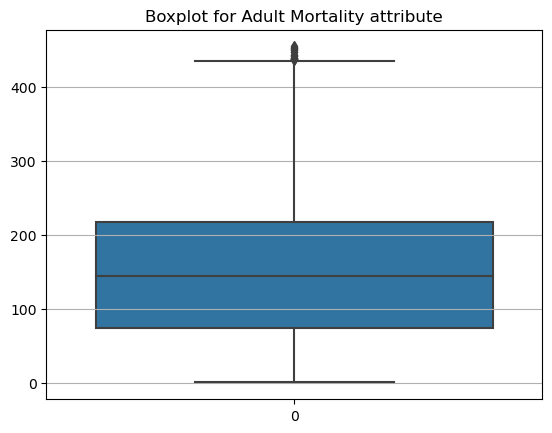

In [640]:
plt.title('Boxplot for Adult Mortality attribute')
sns.boxplot(life_exp['Adult Mortality'],labels=['Adult Mortality'])
plt.grid(axis='y')

### Replacing outlier for infant death rate attribute with mode values

In [641]:
outlier_subset=find_outlier_subset(life_exp,'infant deaths')
replace_outlier_with_mode(life_exp,'infant deaths',outlier_subset)

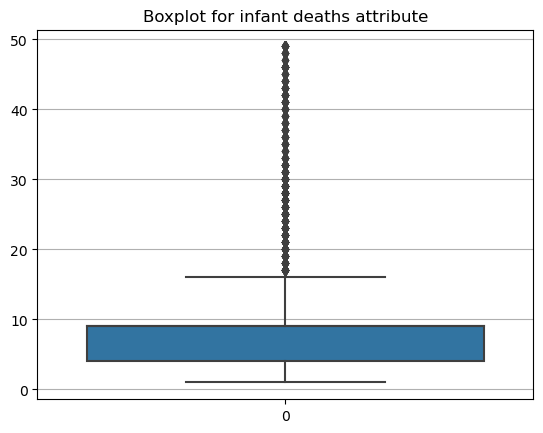

In [642]:
#Boxplot after replacing outliers with medeian values
plt.title('Boxplot for infant deaths attribute')
sns.boxplot(life_exp['infant deaths'],labels=['infant deaths'])
plt.grid(axis='y')

In [643]:
life_exp['infant deaths'].median()

9.0

### Replacing outlier for percentage expenditure rate attribute with median values


In [644]:
outlier_subset=find_outlier_subset(life_exp,'percentage expenditure')
replace_outlier_with_median(life_exp,'percentage expenditure',outlier_subset)


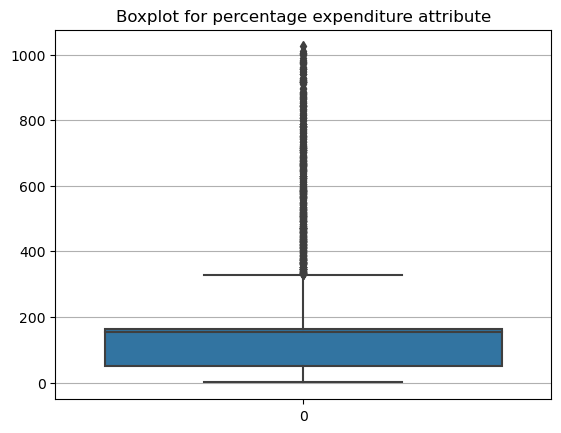

In [645]:
#Boxplot after replacing outliers with median value   s
plt.title('Boxplot for percentage expenditure attribute')
sns.boxplot(life_exp['percentage expenditure'],labels=['percentage expenditure'])
plt.grid(axis='y')

### Replacing outlier for 'Hepatitis B' attribute with median values

In [646]:
outlier_subset=find_outlier_subset(life_exp,'Hepatitis B')
replace_outlier_with_median(life_exp,'Hepatitis B',outlier_subset)

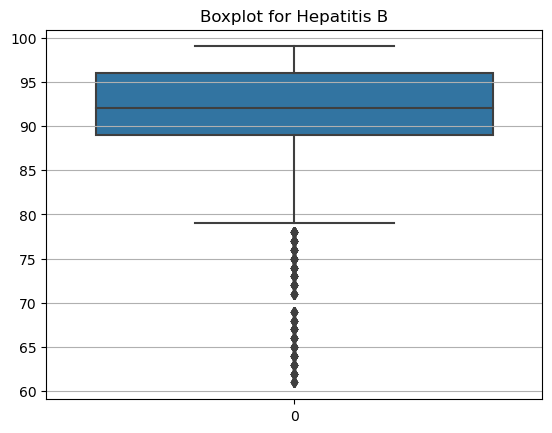

In [647]:
#Boxplot after replacing outliers with median values
plt.title('Boxplot for Hepatitis B')
sns.boxplot(life_exp['Hepatitis B'],labels=['Hepatitis B'])
plt.grid(axis='y')

### Replacing outlier for 'Measles' attribute with median values

In [648]:
outlier_subset=find_outlier_subset(life_exp,'Measles')
replace_outlier_with_mode(life_exp,'Measles',outlier_subset)

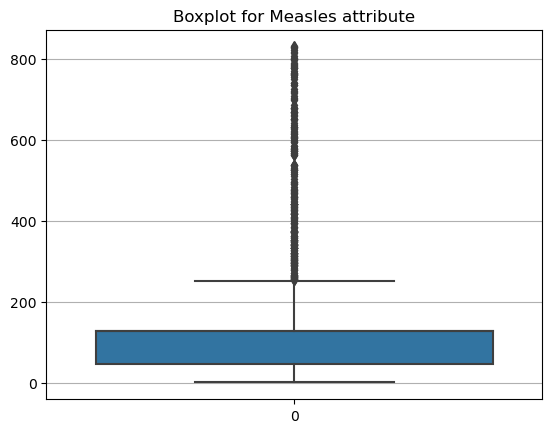

In [649]:
#Boxplot after replacing outliers with mode values
plt.title('Boxplot for Measles attribute')
sns.boxplot(life_exp['Measles'],labels=['Measles'])
plt.grid(axis='y')

In [650]:
outlier_subset=find_outlier_subset(life_exp,'Measles')
replace_outlier_with_median(life_exp,'Measles',outlier_subset)

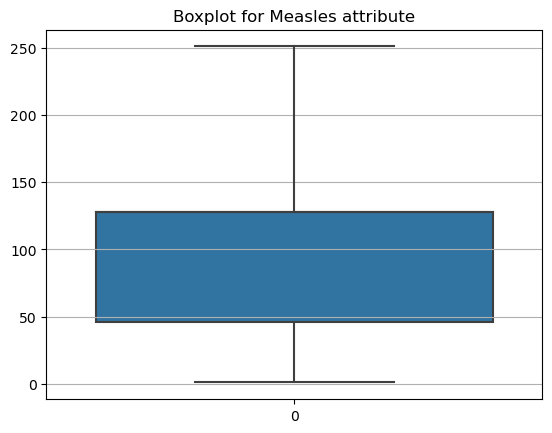

In [651]:
#Boxplot after replacing outliers with median values
plt.title('Boxplot for Measles attribute')
sns.boxplot(life_exp['Measles'],labels=['Measles'])
plt.grid(axis='y')

### Replacing outlier for 'under-five deaths ' attribute with mode values

In [652]:
outlier_subset=find_outlier_subset(life_exp,'under-five deaths ')
replace_outlier_with_mode(life_exp,'under-five deaths ',outlier_subset)

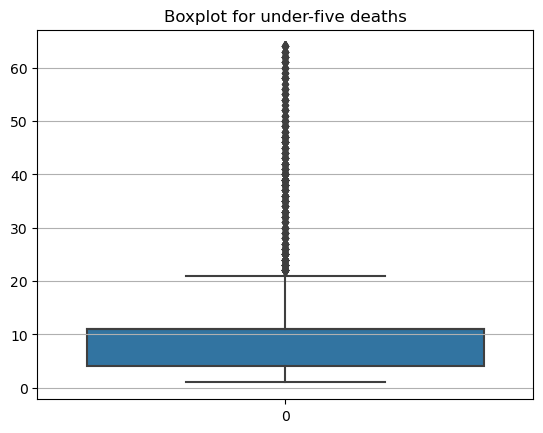

In [653]:
#Boxplot after replacing outliers with mode values
plt.title('Boxplot for under-five deaths')
sns.boxplot(life_exp['under-five deaths '],labels=['under-five deaths '])
plt.grid(axis='y')

### Replacing outlier for 'Total expenditure' attribute with median values

In [654]:
outlier_subset=find_outlier_subset(life_exp,'Total expenditure')
replace_outlier_with_median(life_exp,'Total expenditure',outlier_subset)

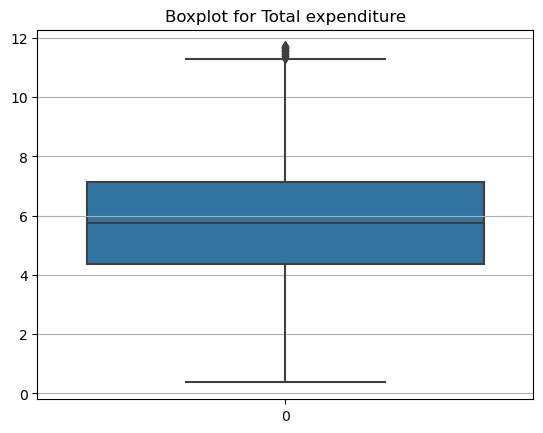

In [655]:
#Boxplot after replacing outliers with median values
plt.title('Boxplot for Total expenditure')
sns.boxplot(life_exp['Total expenditure'],labels=['Total expenditure'])
plt.grid(axis='y')

### Replacing outlier for ' HIV/AIDS' attribute with median values

In [656]:
outlier_subset=find_outlier_subset(life_exp,' HIV/AIDS')
replace_outlier_with_median(life_exp,' HIV/AIDS',outlier_subset)

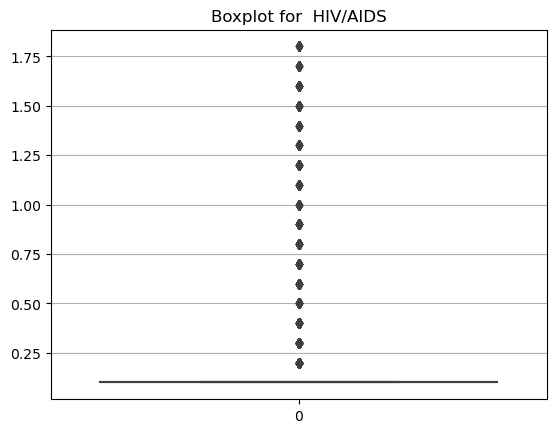

In [657]:
#Boxplot after replacing outliers with median values
plt.title('Boxplot for  HIV/AIDS')
sns.boxplot(life_exp[' HIV/AIDS'],labels=[' HIV/AIDS'])
plt.grid(axis='y')

### Replacing outlier for ' GDP' attribute with median values

In [658]:
outlier_subset=find_outlier_subset(life_exp,'GDP')
replace_outlier_with_median(life_exp,'GDP',outlier_subset)

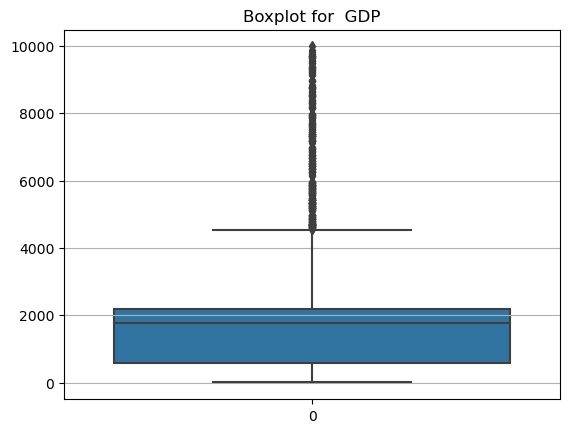

In [659]:
#Boxplot after replacing outliers with median values
plt.title('Boxplot for  GDP')
sns.boxplot(life_exp['GDP'],labels=['GDP'])
plt.grid(axis='y')

### Replacing outlier for 'Diphtheria' attribute with mode values

In [660]:
outlier_subset=find_outlier_subset(life_exp,'Diphtheria')
replace_outlier_with_mode(life_exp,'Diphtheria',outlier_subset)

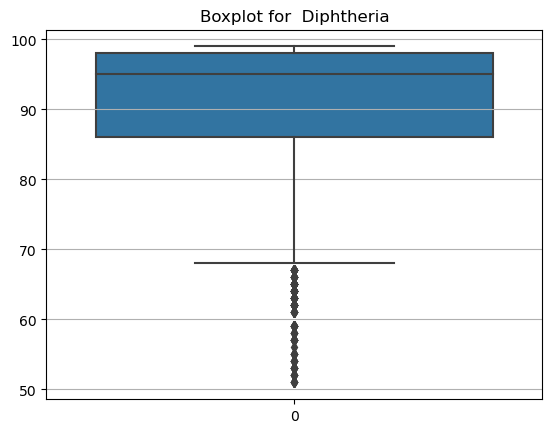

In [661]:
#Boxplot after replacing outliers with median values
plt.title('Boxplot for  Diphtheria')
sns.boxplot(life_exp['Diphtheria'],labels=['Diphtheria'])
plt.grid(axis='y')

### Replacing outlier for 'Polio' attribute with mode values

In [662]:
outlier_subset=find_outlier_subset(life_exp,'Polio')
replace_outlier_with_mode(life_exp,'Polio',outlier_subset)

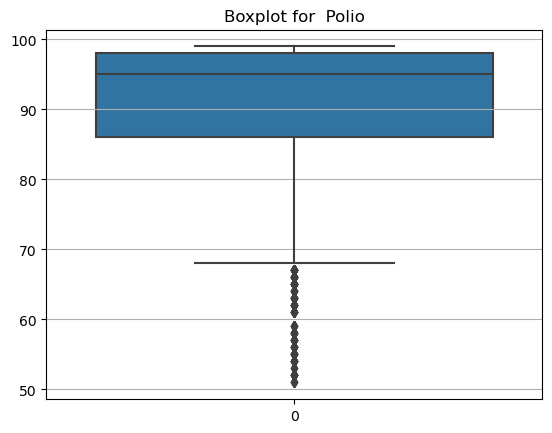

In [663]:
#Boxplot after replacing outliers with mode values
plt.title('Boxplot for  Polio')
sns.boxplot(life_exp['Polio'],labels=['Polio'])
plt.grid(axis='y')

In [664]:
find_outlier_subset(life_exp,'Polio')

1       58.0
2       62.0
3       67.0
5       66.0
6       63.0
        ... 
2891    67.0
2892    67.0
2902    61.0
2903    64.0
2933    67.0
Name: Polio, Length: 203, dtype: float64

### Replacing outlier for 'thinness  1-19 years' attribute with median values

In [665]:
outlier_subset=find_outlier_subset(life_exp,'thinness  1-19 years')
replace_outlier_with_median(life_exp,'thinness  1-19 years',outlier_subset)

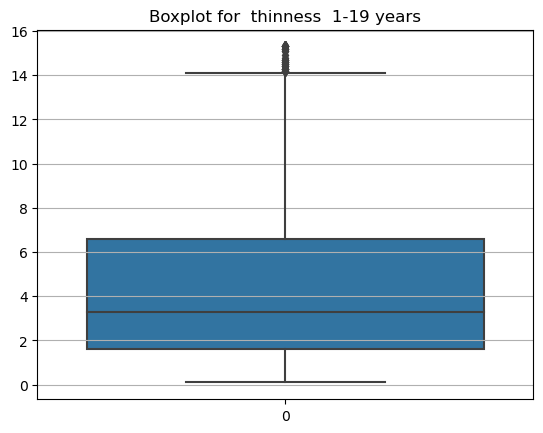

In [666]:
#Boxplot after replacing outliers with median values
plt.title('Boxplot for  thinness  1-19 years')
sns.boxplot(life_exp['thinness  1-19 years'],labels=['thinness  1-19 years'])
plt.grid(axis='y')

### Replacing outlier for 'thinness 5-9 years' attribute with median values

In [667]:
outlier_subset=find_outlier_subset(life_exp,'thinness 5-9 years')
replace_outlier_with_median(life_exp,'thinness 5-9 years',outlier_subset)

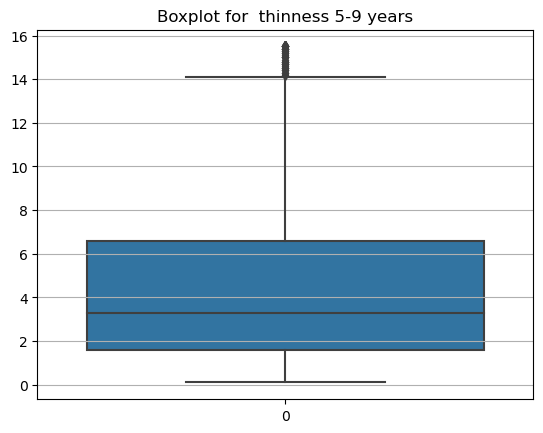

In [668]:
#Boxplot after replacing outliers with median values
plt.title('Boxplot for  thinness 5-9 years')
sns.boxplot(life_exp['thinness 5-9 years'],labels=['thinness 5-9 years'])
plt.grid(axis='y')

### Replacing outlier for 'Schooling' attribute with median values

In [669]:
outlier_subset=find_outlier_subset(life_exp,'Schooling')
replace_outlier_with_median(life_exp,'Schooling',outlier_subset)

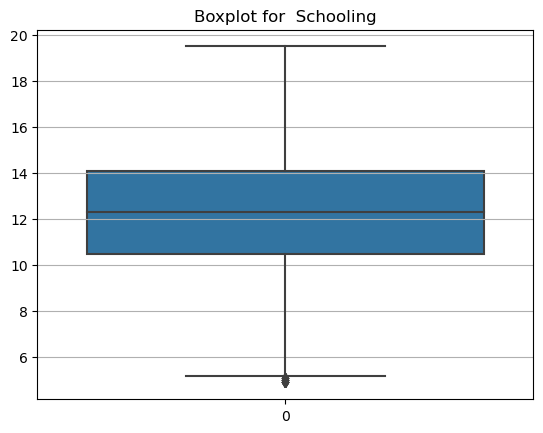

In [670]:
#Boxplot after replacing outliers with median values
plt.title('Boxplot for  Schooling')
sns.boxplot(life_exp['Schooling'],labels=['Schooling'])
plt.grid(axis='y')

## 3.8 Calculate summary statistics for numerical columns, such as mean, median, standard deviation, etc

We will take all the numerical columns from life_exp dataset

In [671]:
life_exp.dtypes

Country                             object
Year                                 int64
Status                              object
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                      float64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                            float64
BMI                                float64
under-five deaths                  float64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
 HIV/AIDS                          float64
GDP                                float64
Population                         float64
thinness  1-19 years               float64
thinness 5-9 years                 float64
Income composition of resources    float64
Schooling                          float64
dtype: object

So other than Country column all other columns are numeric.

In [672]:
# getting all the columns
all_cols = set(life_exp.columns)
 
# removing the desired column
all_cols.remove('Country')
 
all_cols = list(all_cols)
life_exp_num = life_exp[all_cols]

In [673]:
#Numerical columns in life_exp dataset
life_exp_num.columns

Index(['Income composition of resources', 'Population', 'Total expenditure',
       'Measles', 'Hepatitis B', 'Status', 'Schooling', 'Adult Mortality',
       'under-five deaths ', 'Life expectancy', 'percentage expenditure',
       'Year', 'Polio', 'thinness 5-9 years', ' HIV/AIDS', 'infant deaths',
       'Diphtheria', 'BMI', 'Alcohol', 'thinness  1-19 years', 'GDP'],
      dtype='object')

In [674]:
#Descriptive statistics for the life_exp dataset - numerical columns
life_exp_num.describe()

,Income composition of resources,Population,Total expenditure,Measles,Hepatitis B,Schooling,Adult Mortality,under-five deaths,Life expectancy,percentage expenditure,Year,Polio,thinness 5-9 years,HIV/AIDS,infant deaths,Diphtheria,BMI,Alcohol,thinness 1-19 years,GDP
count,2938.000000,2.938000e+03,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000,2938.000000
mean,0.660318,1.023085e+07,5.786043,98.369639,90.406399,12.208305,152.805990,12.534037,69.234717,186.096656,2007.518720,90.057182,4.291491,0.213376,10.423077,90.322668,38.381178,4.546875,4.277332,2032.767562
std,0.153925,5.402242e+07,2.152228,53.823829,8.278288,2.826671,103.551548,12.483030,9.509115,199.622347,4.613841,11.108105,3.421240,0.305162,9.789983,10.635543,19.935375,3.921946,3.390476,1968.993201
min,0.253000,3.400000e+01,0.370000,1.000000,61.000000,4.900000,1.000000,1.000000,36.300000,0.099872,2000.000000,51.000000,0.100000,0.100000,1.000000,51.000000,1.000000,0.010000,0.100000,1.681350
25%,0.554000,4.189172e+05,4.370000,46.000000,89.000000,10.500000,74.000000,4.000000,63.200000,50.811114,2004.000000,86.000000,1.600000,0.100000,4.000000,86.000000,19.400000,1.092500,1.600000,580.486996
50%,0.677000,1.386542e+06,5.755000,128.000000,92.000000,12.300000,144.000000,11.000000,72.100000,155.195208,2008.000000,95.000000,3.300000,0.100000,9.000000,95.000000,43.500000,3.755000,3.300000,1766.947595
75%,0.772000,4.584371e+06,7.150000,128.000000,96.000000,14.100000,218.000000,11.000000,75.600000,162.028400,2012.000000,98.000000,6.600000,0.100000,9.000000,98.000000,56.100000,7.390000,6.600000,2178.012010
max,0.948000,1.293859e+09,11.710000,251.000000,99.000000,19.500000,454.000000,64.000000,89.000000,1024.519543,2015.000000,99.000000,15.500000,1.800000,49.000000,99.000000,87.300000,17.870000,15.300000,9985.369590


## 3.9 Identify and perform label encoding on certain columns:
##      (a) Specify and explain on which columns you perform and why. 
##      (b) Explain what is label encoding and how it changes the dataset.


In [675]:
from sklearn import preprocessing

# label_encoder object knows how to understand word labels. 
label_encoder = preprocessing.LabelEncoder()


### Columns Selection for Label encoding and Explanation:

Country and Status columns in this dataset have categorical values and represented in String format- name of the countries. We can perform label encoding for  Country and Status columns. In this way Country, Status columns will be converted into numerical values and can contribute towards predictive algorithms.

In [676]:
# Encode labels in column 'Country' for life_exp dataset
life_exp['Country']= label_encoder.fit_transform(life_exp['Country']) 

In [677]:
life_exp.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,0,2015,Developing,65.0,263.0,9.0,0.01,71.279624,65.0,128.0,...,99.0,8.16,65.0,0.1,584.259210,33736494.0,3.3,3.3,0.479,10.1
1,0,2014,Developing,59.9,271.0,9.0,0.01,73.523582,62.0,128.0,...,58.0,8.18,62.0,0.1,612.696514,327582.0,3.3,3.3,0.476,10.0
2,0,2013,Developing,59.9,268.0,9.0,0.01,73.219243,64.0,128.0,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,3.3,3.3,0.470,9.9
3,0,2012,Developing,59.5,272.0,9.0,0.01,78.184215,67.0,128.0,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,3.3,3.3,0.463,9.8
4,0,2011,Developing,59.2,275.0,9.0,0.01,7.097109,68.0,128.0,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,3.3,3.3,0.454,9.5


In [678]:
# Encode labels in column 'Status' for life_exp dataset
life_exp['Status']= label_encoder.fit_transform(life_exp['Status']) 

In [679]:
life_exp.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,0,2015,1,65.0,263.0,9.0,0.01,71.279624,65.0,128.0,...,99.0,8.16,65.0,0.1,584.259210,33736494.0,3.3,3.3,0.479,10.1
1,0,2014,1,59.9,271.0,9.0,0.01,73.523582,62.0,128.0,...,58.0,8.18,62.0,0.1,612.696514,327582.0,3.3,3.3,0.476,10.0
2,0,2013,1,59.9,268.0,9.0,0.01,73.219243,64.0,128.0,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,3.3,3.3,0.470,9.9
3,0,2012,1,59.5,272.0,9.0,0.01,78.184215,67.0,128.0,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,3.3,3.3,0.463,9.8
4,0,2011,1,59.2,275.0,9.0,0.01,7.097109,68.0,128.0,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,3.3,3.3,0.454,9.5


### Label Encoding and how it changes the dataset:

Label Encoding is a way to handle and encode categorical values. By Label encoding text categorical field were ranked based on alphabetical value. Here Country and Status columns were initially represeted as categorical value and as a text field. After label encoding Countries were represented as 0,1,2.. values based on their alphabetic rankings.


Reference: https://www.analyticsvidhya.com/blog/2020/03/one-hot-encoding-vs-label-encoding-using-scikit-learn/#:~:text=Label%20encoding%20is%20simpler%20and,lead%20to%20high%2Ddimensional%20data.

## 3.10. Perform data normalization on ‘Adult Mortality', 'BMI', 'GDP’ numerical columns using StandardScaler()

In [680]:
#we will perform data normalization on backed up dataset and only on ‘Adult Mortality', 'BMI', 'GDP’  columns

life_exp_norm=life_exp[['Adult Mortality','BMI','GDP']]

In [681]:

life_exp_norm.head()

,Adult Mortality,BMI,GDP
0,263.0,19.1,584.259210
1,271.0,18.6,612.696514
2,268.0,18.1,631.744976
3,272.0,17.6,669.959000
4,275.0,17.2,63.537231


In [682]:
#importing standardscalar library
from sklearn.preprocessing import StandardScaler
import numpy as np

In [683]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(life_exp_norm)

In [684]:
#Let check after performing transformation
scaled_data

array([[ 1.06432757, -0.96734874, -0.73578463],
       [ 1.14159693, -0.99243406, -0.72133961],
       [ 1.11262092, -1.01751937, -0.71166375],
       ...,
       [-0.77081972, -0.60612024, -1.00343439],
       [-0.08505416, -0.62618849, -0.75390453],
       [-0.08505416, -0.64625674, -0.75452853]])

## 3.11. Compute a correlation matrix and plot the correlation using a heat map and answer the following questions: (2 points)
##         (a) The Features which are Most Positively Correlated with target variable. 
##         (b) The Features which are Most Negatively Correlated with target variable.

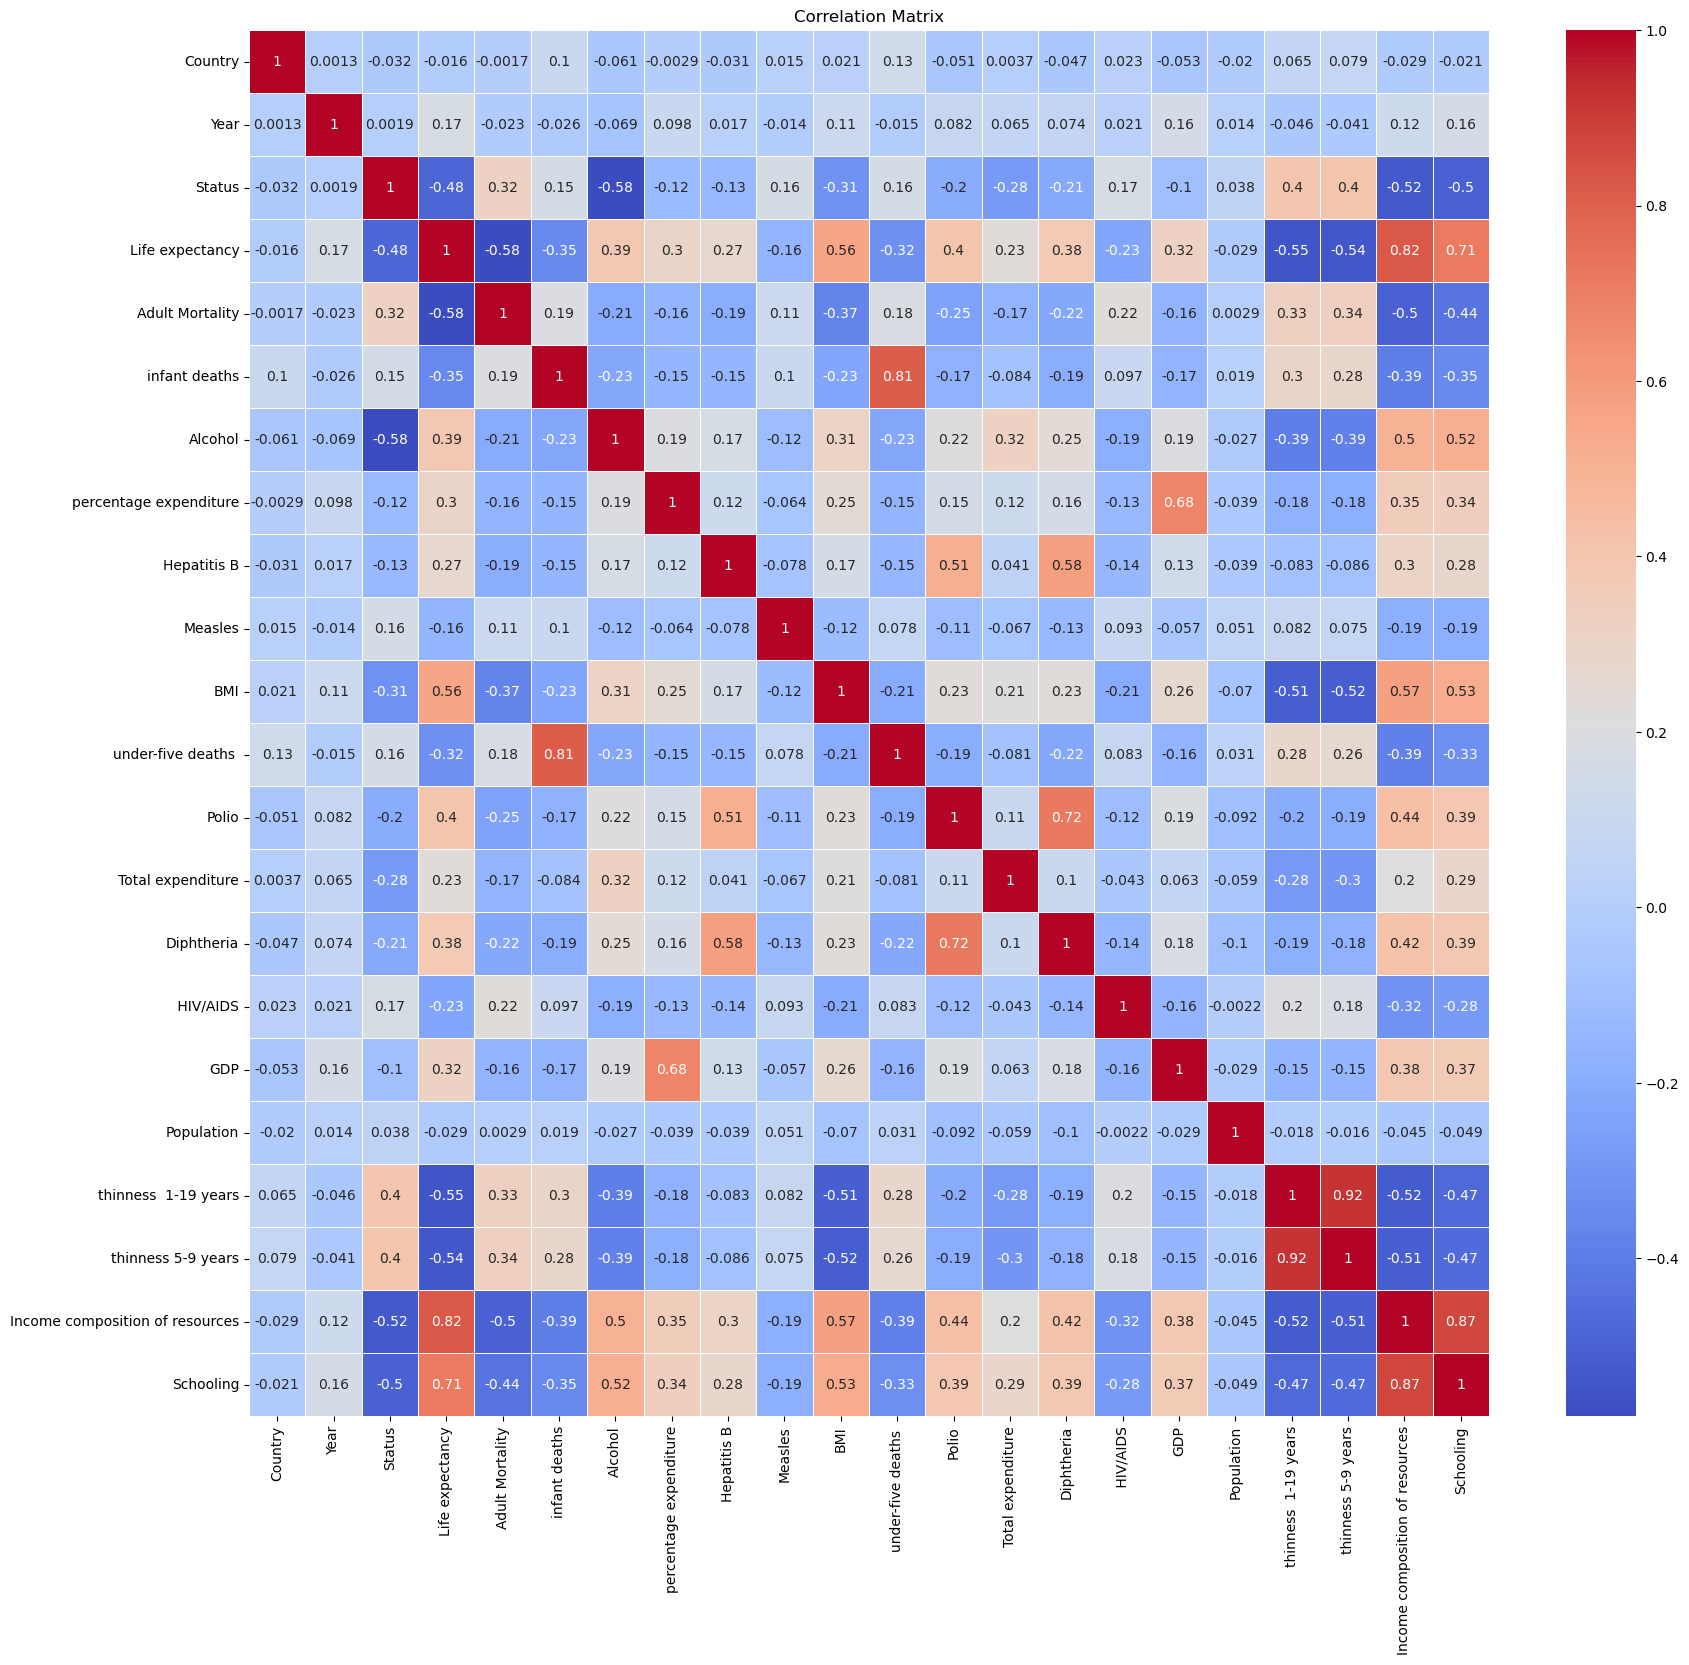

In [685]:
#corr_matrix = heart_train[['chd','alcohol', 'tobacco', 'adiposity','ldl']].corr()
corr_matrix=life_exp.corr()
plt.figure(figsize=(20, 18))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')

plt.show()

#### The Features which are Most Positively Correlated with target variable:

Life Expectancy is the target variable for this dataset. Based correlation heatmap matrix, following variable are highly positively correlated to 'Life Expectancy' variable:

   - a. Schooling - correlation value is 0.71
   - b. Income compositions of resources - correlation values is 0.82
   - c. BMI - correlation value is 0.56

#### The Features which are Most Negatively Correlated with target variable

Based correlation heatmap matrix, following variable are highly negatively correlated to 'Life Expectancy' variable:
   - a. Adult mortality - correlation value is -0.58
   - b. thinness 1-19 years - correlation value is -0.55
   - c. thinness 5-9 years - correlation value is -0.54
   - d. Status - correlation value is -0.48


## 3.12. Drop the column ‘country’ from the dataset and split the dataset into training and testing in a 70:30 split.

We will drop Country column

In [686]:
life_exp_model=life_exp.drop(columns='Country')
life_exp_model.head()

,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,2015,1,65.0,263.0,9.0,0.01,71.279624,65.0,128.0,19.1,...,99.0,8.16,65.0,0.1,584.259210,33736494.0,3.3,3.3,0.479,10.1
1,2014,1,59.9,271.0,9.0,0.01,73.523582,62.0,128.0,18.6,...,58.0,8.18,62.0,0.1,612.696514,327582.0,3.3,3.3,0.476,10.0
2,2013,1,59.9,268.0,9.0,0.01,73.219243,64.0,128.0,18.1,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,3.3,3.3,0.470,9.9
3,2012,1,59.5,272.0,9.0,0.01,78.184215,67.0,128.0,17.6,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,3.3,3.3,0.463,9.8
4,2011,1,59.2,275.0,9.0,0.01,7.097109,68.0,128.0,17.2,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,3.3,3.3,0.454,9.5


#### Splitting the dataset into test and train

In [687]:
from sklearn.model_selection import train_test_split
x=life_exp_model.drop(columns='Life expectancy')
y=life_exp_model[['Life expectancy']]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state = 44)

We will check shape of each test and train data after splitting in into test and train

In [688]:
x_train.shape

(2056, 20)

In [689]:
y_train.shape

(2056, 1)

In [690]:
x_test.shape

(882, 20)

In [691]:
y_test.shape

(882, 1)

## 3.13. Build a linear regression model using the training and testing datasets and compute mean absolute error. 

We will perform scaler transformation on train and test data and perform linear regression from scikit learn library. Then we will fit linear regression on train data and perform prediction on test dataset. And at the end we check regression score and mean absolute error

In [692]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)

In [693]:
from sklearn.linear_model import LinearRegression

In [694]:
y_train=y_train.values.reshape(-1)

In [695]:
linear_regressor = LinearRegression()  # create object for the class
linear_regressor.fit(x_train, y_train)  # perform linear regression


LinearRegression()

In [696]:
#We will run prediction based on the train model on test data to get predicted target data
Y_pred = linear_regressor.predict(x_test) 
Y_pred

array([69.65926069, 76.67431821, 61.26302879, 66.25004082, 74.75649862,
       64.87624463, 70.24928577, 76.74461984, 70.03228605, 76.68637393,
       56.839701  , 82.51016065, 67.68933829, 56.92034961, 68.80871089,
       77.32923556, 66.08634009, 57.75312114, 58.30581219, 67.50617059,
       67.53672108, 70.02087478, 66.69395841, 65.36073781, 60.54558286,
       64.86785179, 64.03762967, 62.88463214, 72.37704758, 77.10704236,
       75.30858616, 77.81238906, 66.13444944, 67.43413177, 58.93417444,
       66.05756281, 71.58220442, 55.27683688, 46.96386614, 62.24455647,
       59.34393001, 75.39077143, 70.36458623, 64.36517248, 73.52882289,
       73.13944405, 69.86647979, 54.7240961 , 58.26075575, 60.0910185 ,
       72.02007458, 81.18088233, 74.51939045, 62.90075883, 50.99340475,
       53.4598114 , 60.03429303, 59.36473907, 70.11875719, 52.77824591,
       79.50751589, 72.43724489, 74.4162178 , 82.73258245, 71.62340127,
       81.21330116, 64.37491587, 69.88243051, 67.94957301, 75.35

In [697]:
### Regression score 

linear_regressor.score(x_test, y_test)


0.7587405401278664

In [698]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
 
mae = mean_absolute_error(y_true=y_test,y_pred=Y_pred)
 
print("Mean Absolute Error :",mae)

mse= mean_squared_error(y_true=y_test,y_pred=Y_pred)
print("Mean Squared Error :",mse)

Mean Absolute Error : 3.3088645185294734
Mean Squared Error : 22.66302496970964


#### Mean Absolute Error is around 3.3 meaning is that there is around 3.3 values difference between the actual and predicted values on average. Also, linear regression gave mean squared error as 22.66

## 3.14. Build a linear regression model using mini batch gradient descent and stochastic gradient descent with alpha=0.0001, learning rate='invscaling', maximum iterations =1000, batch size=32 and compute mean absolute error. 

### Stochastic Gradient Descent

#### Importing libraries for gradient descent

In [699]:
from sklearn.linear_model import SGDRegressor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

To perform gradient descent on the given dataset, we will perform scaler transformation on both test and train data and pass them to Gradient Descent Stochastic function.

In [700]:
x_sgd_train = scaler.fit_transform(x_train)
x_sgd_test = scaler.fit_transform(x_test)

In [701]:
#Creating pipeline with stochastic gradient descent
stochastic_reg=make_pipeline(StandardScaler(),SGDRegressor(alpha=0.0001,learning_rate='invscaling',max_iter=1000))

Fitting the linear regression with stochastic gradient descent on train data.

In [702]:
stochastic_reg.fit(x_sgd_train,y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('sgdregressor', SGDRegressor())])

In [703]:
# Making prediction
y_sgd_pred = stochastic_reg.predict(x_sgd_train)

y_sgd_pred

array([65.72027289, 65.72737979, 60.04122134, ..., 63.05826135,
       74.4363558 , 73.9564171 ])

In [704]:

print("Train: Mean Absolute Error: %.2f"
      % mean_absolute_error(y_train, y_sgd_pred))

Train: Mean Absolute Error: 3.44


In [705]:
print("Train: Mean Squared Error: %.2f"
      %mean_squared_error(y_train, y_sgd_pred, squared=False))

Train: Mean Squared Error: 4.84


So, using Stochastic Gradient Descent on linear regression, we got mean absolute error as 3.40 and Mean squared error as 4.84 . While Mean absolute error got increased a little from normal linear regression, mean squared error got improved from linear regression method. 

## 3.15. Build a linear regression model using Mini batch gradient descent with learning rate = 0.0001, maximum iterations =1000 and batch size=32. Manually without using any scikit learn libraries.

In [706]:
def sum_squared_error(y_true, y_pred):
    return np.sum((y_pred - y_true)**2)


def mini_batch_gradient_descent(x, y, slope, intercept, learning_rate,batch_size,epochs):
    N = len(y)
    
    for epoch in range(epochs): 
       
            # Shuffle the data
            indices = np.random.permutation(N)
            x_shuffled = x[indices]
            y_shuffled = y[indices]
    
        
            for i in range(0, N, batch_size):
                x_batch = x_shuffled[i:i+batch_size]
                y_batch = y_shuffled[i:i+batch_size]
      
               # Calculate predictions
                y_pred = intercept+ slope * x_batch
            
                # Calculate the gradient for the mini-batch
                gradient = (2) * np.sum(x_batch * (y_pred-y_batch))
                db = (2) * np.sum(y_pred - y_batch)
                
                # next step
                slope = slope - learning_rate * gradient
                intercept = intercept - learning_rate * db 
            
            # Calculate and print the sum squared error for monitoring
            SSE = sum_squared_error(y_batch, y_pred)
            print(f"Epoch {epoch + 1}/{epochs}, SSE: {SSE}")    
               
    return slope,intercept

# Given Parameters
slope_initial = 1
intercept_initial = 0
epochs=1000
learning_rate = 0.0001
batch_size=32
x=x_sgd_train.reshape(-1)
y=y_train.reshape(-1)

# Finding Gradient Descent with given parameters
a_optimal,b_optimal = mini_batch_gradient_descent(x, y, slope_initial, intercept_initial, learning_rate,batch_size,epochs)

print(f"Optimal optimal slope: {a_optimal}, Optimal bias: {b_optimal}")

Epoch 1/1000, SSE: 19368.555258435863
Epoch 2/1000, SSE: 10811.966045775722
Epoch 3/1000, SSE: 4178.6055922488895
Epoch 4/1000, SSE: 1915.0153395238387
Epoch 5/1000, SSE: 2378.2717191575935
Epoch 6/1000, SSE: 1429.4478002093135
Epoch 7/1000, SSE: 880.229194174027
Epoch 8/1000, SSE: 677.2978710259302
Epoch 9/1000, SSE: 731.956238598553
Epoch 10/1000, SSE: 625.1239106382695
Epoch 11/1000, SSE: 1466.0860340353706
Epoch 12/1000, SSE: 608.925964979934
Epoch 13/1000, SSE: 652.8133185465745
Epoch 14/1000, SSE: 1173.5386063591957
Epoch 15/1000, SSE: 735.0159858470529
Epoch 16/1000, SSE: 952.6350391829997
Epoch 17/1000, SSE: 486.46309665234287
Epoch 18/1000, SSE: 803.5196279285797
Epoch 19/1000, SSE: 344.2639265809389
Epoch 20/1000, SSE: 578.2714501361829
Epoch 21/1000, SSE: 1167.7539847217654
Epoch 22/1000, SSE: 456.8080579934194
Epoch 23/1000, SSE: 587.8327402411227
Epoch 24/1000, SSE: 902.4514314772707
Epoch 25/1000, SSE: 660.2013237769539
Epoch 26/1000, SSE: 1525.458923285957
Epoch 27/1000,

Here we gave created user defined function - mini_batch_gradient_descent to compute mini batch Gradient Descent on linear regression using batch size 32 and used 1000 epochs. For each iterations we calculated Sum of Squared Error(SSE) and found that it keeps going zigzag on each iterations. Lowest SSE we found at Epoch 541/1000 as 142.3638813218416 whereas at the end of 1000 epoch we found SSE approximately as 441.23633 along with optimal slope and bias as  -0.14421800840034235 and 69.2243572826775. Also, with each run it keeps on changing with each run as we take random data with batch size 32.

## 3.16. Compare the results from each approach and also explain the difference between mini batch gradient descent and stochastic gradient descent..

In Stochastic Gradient Descent using Sklearn library, mean squared error found is 4.84. In minibatch without sklearn sum of squared error keeps fluctuating in order to find global minima and at epoch 1000 it is around 645.65 and keeps on changing due to random selection of data point in each run . So clearly using mini batch with size batch size 32 , mean squared error = (1/batch size) * sum of squared error = (1/32) * 645.65 ~ 20.17 which is still lesser than what we found from Stochastic Gradient Descent. However, mini batch  gives better result than linear regression method.So we can conclude that Stochastic Gradient descent approach is best tahn mini batch and normal liear regression methods.

## Conclusion


Life expectancy of a person is determined by many factors including their Country's GDP, status to their Country's overall health wise behavior. Our analysis shows that Life expectancy of a country might get higher with average BMI of a person in that country along with how the people is getting schooled and income composition. On the contrary, high adult mortality , thinness in a person under 17 years old might lower life expectancy. We have performed simple linear regression, linear regression with stochastic gradient descent and mini batch gradient descent to predict life expectancy based on the given attributes. With Stochastic gradient descent we are able to predict life expectancy with MSE at 4.84 which is better prediction model than the other two.